# XAI and Cancer Screening

## Load Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import os
import joblib
import shap 

fp_data_folder = "../data"
fp_checkpoint_folder = "../tree_featsel_checkpoints"
fp_model_checkpoint_folder = os.path.join(fp_checkpoint_folder, "models")
fp_preprocessing_checkpoint_folder = os.path.join(fp_checkpoint_folder, "preprocessing")
fp_tuning_checkpoint_folder = os.path.join(fp_checkpoint_folder, "tuning")
fp_results_checkpoint_folder = os.path.join(fp_checkpoint_folder, "results")
fp_lung_data_file = os.path.join(fp_data_folder, "schs_200lung.csv")
fp_crc_data_file = os.path.join(fp_data_folder, "colorectalcancers_schs_pgs.csv")

fp_crc_scaler_file = os.path.join(fp_preprocessing_checkpoint_folder, "crc_minmax_scaler.pickle")
fp_crc_encoder_file = os.path.join(fp_preprocessing_checkpoint_folder, "crc_encoder.pickle")
fp_crc_tuning_w_pc_file = os.path.join(fp_tuning_checkpoint_folder, "crc_tuning_w_pc.csv")
fp_crc_tuning_wo_pc_file = os.path.join(fp_tuning_checkpoint_folder, "crc_tuning_wo_pc.csv")

seed = 2024

## Load Data

In [2]:
crc_df = pd.read_csv(fp_crc_data_file, index_col=0)
crc_df

,Follow-up time,colorectal cancer,"Sex (1=Male, 2=Female)",Age_interview,PC1,PC2,PC3,BMI,telomere length,aHEI2010score,aMED,DASH,SBP,DBP,Leisure screen time,smoke_never(0)_ex(1)_current(2),alcohol_DailyandWeekly(1)vsMonthlyandNonDrinkers(0),Prevalent_diabetes,z_pgs000055,z_pgs000734
SERNO,,,,,,,,,,,,,,,,,,,,
15409,0.156057,1,1,61.021218,0.006129,0.004028,-0.002208,60.232005,0.792163,54.01064,4,27,131.0,80.0,3.5,2,0,0,-0.359262,-0.361187
44317,10.932238,1,2,53.670089,0.002519,0.002770,-0.006793,35.133553,1.592871,52.81731,7,29,148.0,74.0,3.5,0,0,1,-0.253785,1.780125
1260,1.434634,1,1,49.905544,-0.009109,-0.007086,-0.004642,33.023661,1.069176,42.32520,4,20,198.0,106.0,3.5,0,0,0,-0.191556,-0.604904
83659,4.676249,1,2,51.767283,0.004248,-0.008782,-0.001898,32.455678,0.951540,47.58434,5,23,190.0,111.0,3.5,0,0,0,0.071767,0.006659
72575,3.356605,1,1,62.121834,0.007658,-0.005053,0.007278,32.455678,0.922957,36.64795,1,17,147.0,81.0,3.5,2,0,0,-0.574599,-1.298561
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34642,3.501711,0,1,63.994524,-0.001979,0.000314,-0.020852,13.336382,1.456892,57.87610,3,19,118.0,62.0,1.5,2,1,0,-0.133379,-1.643265
33547,4.769336,0,1,62.302533,0.006234,-0.008165,0.001225,13.064305,1.043289,39.86306,4,27,123.0,64.0,3.5,0,0,0,0.097645,-0.697939
79642,12.561259,0,2,72.071184,-0.005098,0.006695,-0.001021,12.982271,0.938813,49.97783,6,29,152.0,82.0,3.5,2,0,0,0.752815,0.789168


In [3]:
crc_df.columns

Index(['Follow-up time', 'colorectal cancer', 'Sex (1=Male, 2=Female)',
       'Age_interview', 'PC1', 'PC2', 'PC3', 'BMI', 'telomere length',
       'aHEI2010score', 'aMED', 'DASH', 'SBP', 'DBP', 'Leisure screen time',
       'smoke_never(0)_ex(1)_current(2)',
       'alcohol_DailyandWeekly(1)vsMonthlyandNonDrinkers(0)',
       'Prevalent_diabetes', 'z_pgs000055', 'z_pgs000734'],
      dtype='object')

In [4]:
crc_df['aMED'].describe() # Assume this is also a index (continuous)

count    22901.000000
mean         4.123051
std          1.544609
min          0.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          9.000000
Name: aMED, dtype: float64

In [5]:
crc_df['DASH'].describe() # Assume this is a index (continuous)

count    22901.000000
mean        24.443125
std          4.339849
min          9.000000
25%         21.000000
50%         24.000000
75%         27.000000
max         39.000000
Name: DASH, dtype: float64

### Data Exploration

In [6]:
def get_col_types_crc(df):
    categorical_cols = [
        "Sex (1=Male, 2=Female)", "alcohol_DailyandWeekly(1)vsMonthlyandNonDrinkers(0)", 
        "smoke_never(0)_ex(1)_current(2)", "Prevalent_diabetes"]
    target_col = "colorectal cancer"
    continuous_cols = [col for col in df.columns if col not in categorical_cols + [target_col]]
    print("Categorical Columns:", categorical_cols)
    print("Continuous Columns:", continuous_cols)
    print("Target Column:", target_col)
    return categorical_cols, continuous_cols, target_col

crc_categorical_cols, crc_continuous_cols, crc_target_col = get_col_types_crc(crc_df)

Categorical Columns: ['Sex (1=Male, 2=Female)', 'alcohol_DailyandWeekly(1)vsMonthlyandNonDrinkers(0)', 'smoke_never(0)_ex(1)_current(2)', 'Prevalent_diabetes']
Continuous Columns: ['Follow-up time', 'Age_interview', 'PC1', 'PC2', 'PC3', 'BMI', 'telomere length', 'aHEI2010score', 'aMED', 'DASH', 'SBP', 'DBP', 'Leisure screen time', 'z_pgs000055', 'z_pgs000734']
Target Column: colorectal cancer


In [7]:
crc_df[crc_continuous_cols].describe()

,Follow-up time,Age_interview,PC1,PC2,PC3,BMI,telomere length,aHEI2010score,aMED,DASH,SBP,DBP,Leisure screen time,z_pgs000055,z_pgs000734
count,22901.000000,22901.000000,22901.000000,22901.000000,22901.000000,22901.000000,21448.000000,22901.000000,22901.000000,22901.000000,22112.000000,22112.000000,22901.000000,22901.000000,22901.000000
mean,11.910751,55.656939,-0.000013,0.000010,0.000012,23.161131,1.020581,50.569572,4.123051,24.443125,141.444826,83.872015,3.276909,-0.003770,-0.002622
std,3.726860,7.503421,0.006487,0.006487,0.006475,3.246356,0.225068,7.335265,1.544609,4.339849,25.139474,12.678531,0.939833,0.998590,0.998704
min,0.000000,43.655031,-0.014307,-0.088323,-0.034615,12.046485,0.185851,17.032450,0.000000,9.000000,39.000000,41.000000,1.500000,-3.930796,-3.930796
25%,11.509925,49.163587,-0.006400,-0.001928,-0.003478,21.096191,0.867896,45.787070,3.000000,21.000000,123.000000,75.000000,3.500000,-0.677774,-0.677574
50%,12.958248,54.666667,0.000040,0.000787,0.000503,23.111911,0.998880,50.440790,4.000000,24.000000,140.000000,83.000000,3.500000,-0.002573,-0.000822
75%,14.162902,61.054073,0.006666,0.003331,0.004194,24.801587,1.150037,55.370170,5.000000,27.000000,158.000000,92.000000,3.500000,0.671512,0.673108
max,21.527721,75.449692,0.010716,0.021266,0.025272,60.232005,2.861107,80.483520,9.000000,39.000000,253.000000,146.000000,8.500000,4.094366,3.704674


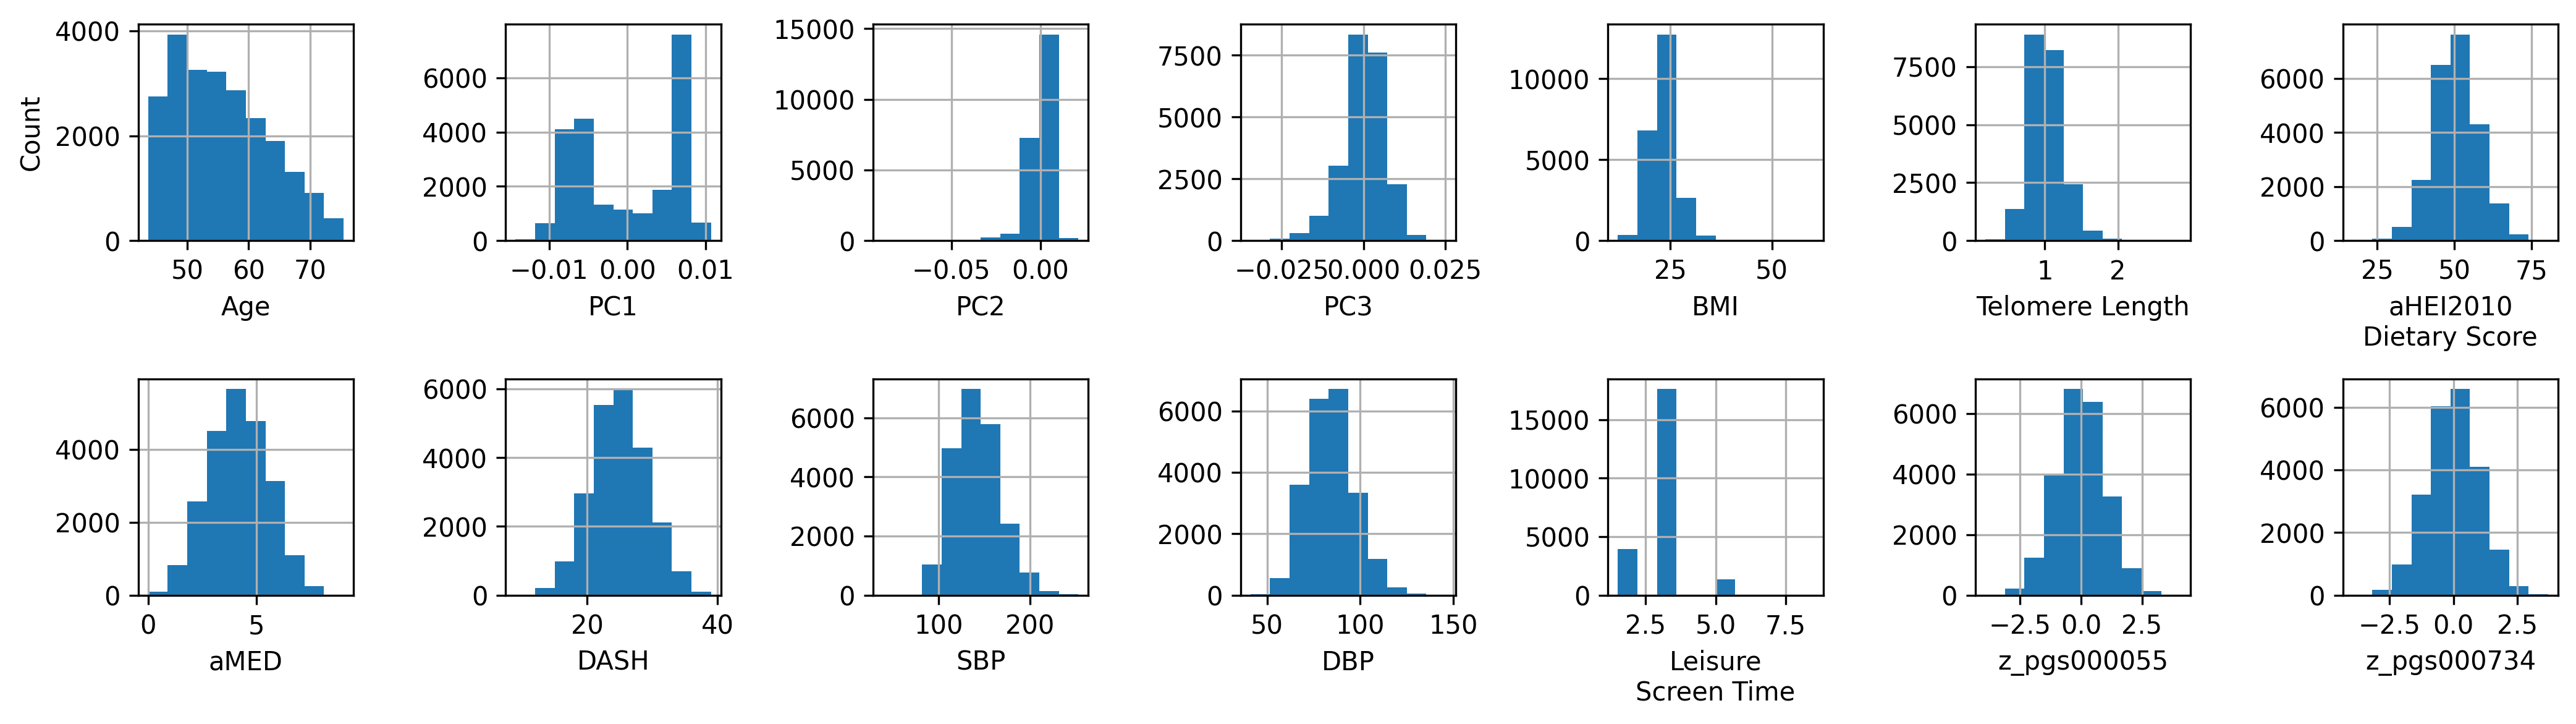

In [8]:
def show_continuous_features_crc(df, continuous_cols, clean_col_names):
    from math import ceil
    nrows = 2
    ncols = ceil(len(continuous_cols)/2)
    size = 2
    fig, axes = plt.subplots(nrows, ncols, dpi=300, figsize=(size*ncols, size*nrows))
    axes = axes.flatten()
    axes[0].set_ylabel("Count")
    for i, col in enumerate(continuous_cols):
        df[col].hist(bins=10, ax=axes[i])
        axes[i].set_xlabel(clean_col_names[i])
    for j in range(i+1, ncols*nrows):
        axes[j].set_axis_off()
    plt.tight_layout()
    
show_continuous_features_crc(
    crc_df, crc_continuous_cols[1:], 
    ["Age", "PC1", "PC2", "PC3", "BMI", "Telomere Length", "aHEI2010\nDietary Score", 
     'aMED', 'DASH', "SBP", "DBP", "Leisure\nScreen Time", 'z_pgs000055', 'z_pgs000734']
)      

In [9]:
for col in crc_categorical_cols + [crc_target_col]:
    print(crc_df[col].value_counts())

Sex (1=Male, 2=Female)
2    12902
1     9999
Name: count, dtype: int64
alcohol_DailyandWeekly(1)vsMonthlyandNonDrinkers(0)
0    20179
1     2722
Name: count, dtype: int64
smoke_never(0)_ex(1)_current(2)
0    16537
2     3902
1     2462
Name: count, dtype: int64
Prevalent_diabetes
0    21176
1     1725
Name: count, dtype: int64
colorectal cancer
0    22311
1      590
Name: count, dtype: int64


### Data Processing

#### Drop NA

In [10]:
def drop_na(df):
    df = df.copy()
    display(df.isna().sum())
    print(f"DataFrame Shape Before Dropping NA: {df.shape}")
    df = df.dropna()
    print(f"DataFrame Shape Before Dropping NA: {df.shape}")
    return df
crc_df = drop_na(crc_df)
display(crc_df)

Follow-up time                                            0
colorectal cancer                                         0
Sex (1=Male, 2=Female)                                    0
Age_interview                                             0
PC1                                                       0
PC2                                                       0
PC3                                                       0
BMI                                                       0
telomere length                                        1453
aHEI2010score                                             0
aMED                                                      0
DASH                                                      0
SBP                                                     789
DBP                                                     789
Leisure screen time                                       0
smoke_never(0)_ex(1)_current(2)                           0
alcohol_DailyandWeekly(1)vsMonthlyandNon

DataFrame Shape Before Dropping NA: (22901, 20)
DataFrame Shape Before Dropping NA: (20689, 20)


,Follow-up time,colorectal cancer,"Sex (1=Male, 2=Female)",Age_interview,PC1,PC2,PC3,BMI,telomere length,aHEI2010score,aMED,DASH,SBP,DBP,Leisure screen time,smoke_never(0)_ex(1)_current(2),alcohol_DailyandWeekly(1)vsMonthlyandNonDrinkers(0),Prevalent_diabetes,z_pgs000055,z_pgs000734
SERNO,,,,,,,,,,,,,,,,,,,,
15409,0.156057,1,1,61.021218,0.006129,0.004028,-0.002208,60.232005,0.792163,54.01064,4,27,131.0,80.0,3.5,2,0,0,-0.359262,-0.361187
44317,10.932238,1,2,53.670089,0.002519,0.002770,-0.006793,35.133553,1.592871,52.81731,7,29,148.0,74.0,3.5,0,0,1,-0.253785,1.780125
1260,1.434634,1,1,49.905544,-0.009109,-0.007086,-0.004642,33.023661,1.069176,42.32520,4,20,198.0,106.0,3.5,0,0,0,-0.191556,-0.604904
83659,4.676249,1,2,51.767283,0.004248,-0.008782,-0.001898,32.455678,0.951540,47.58434,5,23,190.0,111.0,3.5,0,0,0,0.071767,0.006659
72575,3.356605,1,1,62.121834,0.007658,-0.005053,0.007278,32.455678,0.922957,36.64795,1,17,147.0,81.0,3.5,2,0,0,-0.574599,-1.298561
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34642,3.501711,0,1,63.994524,-0.001979,0.000314,-0.020852,13.336382,1.456892,57.87610,3,19,118.0,62.0,1.5,2,1,0,-0.133379,-1.643265
33547,4.769336,0,1,62.302533,0.006234,-0.008165,0.001225,13.064305,1.043289,39.86306,4,27,123.0,64.0,3.5,0,0,0,0.097645,-0.697939
79642,12.561259,0,2,72.071184,-0.005098,0.006695,-0.001021,12.982271,0.938813,49.97783,6,29,152.0,82.0,3.5,2,0,0,0.752815,0.789168


In [11]:
for col in crc_categorical_cols + [crc_target_col]:
    print(crc_df[col].value_counts())

Sex (1=Male, 2=Female)
2    11556
1     9133
Name: count, dtype: int64
alcohol_DailyandWeekly(1)vsMonthlyandNonDrinkers(0)
0    18188
1     2501
Name: count, dtype: int64
smoke_never(0)_ex(1)_current(2)
0    14893
2     3570
1     2226
Name: count, dtype: int64
Prevalent_diabetes
0    19144
1     1545
Name: count, dtype: int64
colorectal cancer
0    20156
1      533
Name: count, dtype: int64


#### Data Split

In [12]:
# Split data
def split_data_stratified(df, target_col, val_prop, test_prop, seed):
    np.random.seed(seed)
    df = df.copy()
    data_size = len(df)
    train_prop = 1 - val_prop - test_prop
    train_dfs, val_dfs, test_dfs = [], [], []
    # From each class, choose the same proportion of val and test
    for target, group_df in df.groupby(target_col):
        group_size = len(group_df)
        indices = np.array([i for i in range(group_size)])
        np.random.shuffle(indices)
        train_size, val_size = round(train_prop * group_size), round(val_prop * group_size)
        train_indices, val_indices, test_indices = (
            indices[:train_size], indices[train_size:train_size+val_size], indices[train_size+val_size:])
        train_dfs.append(group_df.iloc[train_indices])
        val_dfs.append(group_df.iloc[val_indices])
        test_dfs.append(group_df.iloc[test_indices])
    return dict(
        train_df=pd.concat(train_dfs), val_df=pd.concat(val_dfs), test_df=pd.concat(test_dfs)
    )

crc_split_dict = split_data_stratified(crc_df, crc_target_col, val_prop=0.1, test_prop=0.1, seed=2023)
for label, cur_df in crc_split_dict.items():
    print(label,":")
    print("- Total Number of Samples:", len(cur_df))
    print("- Class Distribution:", cur_df[crc_target_col].value_counts()/len(cur_df))

train_df :
- Total Number of Samples: 16551
- Class Distribution: colorectal cancer
0    0.974261
1    0.025739
Name: count, dtype: float64
val_df :
- Total Number of Samples: 2069
- Class Distribution: colorectal cancer
0    0.974384
1    0.025616
Name: count, dtype: float64
test_df :
- Total Number of Samples: 2069
- Class Distribution: colorectal cancer
0    0.9739
1    0.0261
Name: count, dtype: float64


#### Data Normalisation

In [13]:
def normalise_data(train_df, val_df, test_df, continuous_cols):
    train_df, val_df, test_df = train_df.copy(), val_df.copy(), test_df.copy()
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    train_df[continuous_cols] = scaler.fit_transform(train_df[continuous_cols])
    val_df[continuous_cols] = scaler.transform(val_df[continuous_cols])
    test_df[continuous_cols] = scaler.transform(test_df[continuous_cols])
    return dict(
        train_df=train_df, val_df=val_df, test_df=test_df
    ), scaler

crc_split_dict_scaled, crc_scaler = normalise_data(**crc_split_dict, continuous_cols=crc_continuous_cols)
for label, cur_df in crc_split_dict_scaled.items():
    print(label,":")
    display(cur_df[crc_continuous_cols].describe())

train_df :


,Follow-up time,Age_interview,PC1,PC2,PC3,BMI,telomere length,aHEI2010score,aMED,DASH,SBP,DBP,Leisure screen time,z_pgs000055,z_pgs000734
count,16551.000000,16551.000000,16551.000000,16551.000000,16551.000000,16551.000000,16551.000000,16551.000000,16551.000000,16551.000000,16551.000000,16551.000000,16551.000000,16551.000000,16551.000000
mean,0.553856,0.371239,0.570042,0.806157,0.577915,0.231040,0.337804,0.529189,0.459261,0.515278,0.482370,0.409280,0.253174,0.477978,0.502576
std,0.166838,0.232174,0.259310,0.059651,0.108471,0.067093,0.091066,0.115345,0.171544,0.144904,0.117253,0.132672,0.133797,0.128026,0.134354
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.540478,0.170068,0.314624,0.788498,0.519749,0.187810,0.276016,0.453745,0.333333,0.400000,0.396226,0.315789,0.285714,0.391269,0.411981
50%,0.603444,0.341255,0.567771,0.813531,0.586571,0.229642,0.329450,0.527065,0.444444,0.500000,0.476415,0.400000,0.285714,0.477174,0.502537
75%,0.659856,0.537114,0.838370,0.836404,0.647835,0.264708,0.390981,0.604368,0.555556,0.600000,0.556604,0.494737,0.285714,0.564173,0.593062
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


val_df :


,Follow-up time,Age_interview,PC1,PC2,PC3,BMI,telomere length,aHEI2010score,aMED,DASH,SBP,DBP,Leisure screen time,z_pgs000055,z_pgs000734
count,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000
mean,0.558276,0.374698,0.565436,0.805977,0.578352,0.230745,0.336920,0.529035,0.456152,0.514210,0.483929,0.410012,0.255472,0.476892,0.504397
std,0.159197,0.238406,0.261143,0.056064,0.107595,0.069611,0.087676,0.117102,0.173408,0.143952,0.121594,0.135141,0.132062,0.129137,0.132968
min,0.000129,0.026178,0.010390,0.180192,0.047351,0.031830,0.062052,0.088988,0.000000,0.033333,0.160377,-0.021053,0.000000,-0.021633,-0.022763
25%,0.541763,0.169379,0.313738,0.788358,0.521285,0.183825,0.276978,0.455529,0.333333,0.433333,0.396226,0.315789,0.285714,0.390300,0.414907
50%,0.608841,0.341514,0.548495,0.811468,0.584985,0.229642,0.330397,0.525455,0.444444,0.500000,0.476415,0.400000,0.285714,0.477472,0.506354
75%,0.659214,0.545595,0.840654,0.835118,0.645153,0.265526,0.388790,0.607244,0.555556,0.600000,0.561321,0.494737,0.285714,0.565029,0.594908
max,0.812002,0.976922,0.980915,0.930599,0.892746,0.624832,0.771096,0.922496,0.888889,0.933333,0.995283,0.926316,0.571429,0.866387,0.916243


test_df :


,Follow-up time,Age_interview,PC1,PC2,PC3,BMI,telomere length,aHEI2010score,aMED,DASH,SBP,DBP,Leisure screen time,z_pgs000055,z_pgs000734
count,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000
mean,0.559944,0.366436,0.578579,0.808209,0.577025,0.231003,0.335816,0.525115,0.458461,0.508925,0.483398,0.412276,0.256508,0.483249,0.513376
std,0.163656,0.234480,0.256942,0.054682,0.104783,0.066843,0.090522,0.117118,0.170545,0.144647,0.117700,0.132063,0.138313,0.122090,0.130775
min,0.002827,0.027039,0.083922,0.250363,0.106571,0.051600,-0.005907,0.092999,0.000000,0.066667,0.198113,0.021053,0.000000,0.096996,0.066628
25%,0.544847,0.163179,0.321682,0.789846,0.517301,0.190139,0.272603,0.445954,0.333333,0.400000,0.400943,0.315789,0.285714,0.401668,0.421015
50%,0.603701,0.330664,0.598916,0.814255,0.583679,0.229642,0.325665,0.524860,0.444444,0.500000,0.476415,0.410526,0.285714,0.486080,0.515601
75%,0.663454,0.530009,0.839053,0.837630,0.643756,0.265526,0.393627,0.602028,0.555556,0.600000,0.561321,0.494737,0.285714,0.566480,0.602082
max,0.799794,0.974942,0.980643,0.940874,0.895354,0.941185,0.818592,0.911837,0.888889,0.966667,1.009434,1.010526,1.000000,0.853316,0.908775


In [14]:
# Save scaler
joblib.dump(crc_scaler, fp_crc_scaler_file) 

['../tree_featsel_checkpoints\\preprocessing\\crc_minmax_scaler.pickle']

#### Binarisation + One-Hot Encoding

In [15]:
def one_hot_encode_data(train_df, val_df, test_df, categorical_cols):
    train_df, val_df, test_df = train_df.copy(), val_df.copy(), test_df.copy()
    
    # Binarise "Sex" col
    prev_col_name = "Sex (1=Male, 2=Female)"
    new_col_name = "Sex (0=Male, 1=Female)"
    train_df[new_col_name] = train_df[prev_col_name] - 1
    val_df[new_col_name] = val_df[prev_col_name] - 1
    test_df[new_col_name] = test_df[prev_col_name] - 1

    # One-Hot Encode "smoke_never" col
    prev_col_name =  'smoke_never(0)_ex(1)_current(2)'
    new_col_names = ["smoke_ex(1)", "smoke_current(2)"]
    from sklearn.preprocessing import OneHotEncoder
    encoder = OneHotEncoder(drop="first")
    train_df[new_col_names] = encoder.fit_transform(train_df[[prev_col_name]]).toarray()
    val_df[new_col_names] = encoder.transform(val_df[[prev_col_name]]).toarray()
    test_df[new_col_names] = encoder.transform(test_df[[prev_col_name]]).toarray()
    
    train_df = train_df.drop(["Sex (1=Male, 2=Female)", 'smoke_never(0)_ex(1)_current(2)'], axis=1)
    val_df = val_df.drop(["Sex (1=Male, 2=Female)", 'smoke_never(0)_ex(1)_current(2)'], axis=1)
    test_df = test_df.drop(["Sex (1=Male, 2=Female)", 'smoke_never(0)_ex(1)_current(2)'], axis=1)
    
    return dict(
        train_df=train_df, val_df=val_df, test_df=test_df
    ), encoder

crc_split_dict_encoded, crc_encoder = one_hot_encode_data(
    **crc_split_dict_scaled, categorical_cols=crc_categorical_cols)

for label, cur_df in crc_split_dict_encoded.items():
    print(label,":")
    display(cur_df)

train_df :


,Follow-up time,colorectal cancer,Age_interview,PC1,PC2,PC3,BMI,telomere length,aHEI2010score,aMED,...,SBP,DBP,Leisure screen time,alcohol_DailyandWeekly(1)vsMonthlyandNonDrinkers(0),Prevalent_diabetes,z_pgs000055,z_pgs000734,"Sex (0=Male, 1=Female)",smoke_ex(1),smoke_current(2)
SERNO,,,,,,,,,,,,,,,,,,,,,
3899,0.667181,0,0.418497,0.861429,0.780367,0.739772,0.275039,0.288265,0.496078,0.555556,...,0.504717,0.378947,0.285714,0,0,0.462569,0.600765,1,0.0,0.0
69938,0.574145,0,0.744166,0.927537,0.783693,0.696657,0.166341,0.256940,0.494399,0.222222,...,0.825472,0.768421,0.285714,0,0,0.484173,0.664786,0,0.0,1.0
26886,0.683500,0,0.304745,0.315843,0.828388,0.517944,0.187415,0.267911,0.436290,0.666667,...,0.509434,0.600000,0.285714,0,0,0.361024,0.495233,0,1.0,0.0
61080,0.617579,0,0.638681,0.297428,0.812236,0.576227,0.195226,0.335164,0.739064,0.555556,...,0.542453,0.368421,0.285714,0,1,0.397901,0.274174,0,0.0,0.0
16927,0.721537,0,0.585465,0.870866,0.787384,0.823248,0.166496,0.311181,0.386709,0.444444,...,0.471698,0.336842,0.285714,0,0,0.398314,0.440302,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44317,0.512850,1,0.314992,0.672925,0.831226,0.464582,0.479129,0.576866,0.563976,0.777778,...,0.514151,0.305263,0.285714,0,1,0.446464,0.742209,1,0.0,0.0
80088,0.374968,1,0.768363,0.352994,0.801927,0.609621,0.187415,0.238195,0.427800,0.333333,...,0.594340,0.494737,0.000000,0,0,0.341554,0.438764,0,0.0,1.0
25575,0.688255,1,0.272712,0.669583,0.850026,0.521766,0.219738,0.239611,0.510576,0.222222,...,0.429245,0.494737,0.000000,1,0,0.621212,0.513013,0,1.0,0.0


val_df :


,Follow-up time,colorectal cancer,Age_interview,PC1,PC2,PC3,BMI,telomere length,aHEI2010score,aMED,...,SBP,DBP,Leisure screen time,alcohol_DailyandWeekly(1)vsMonthlyandNonDrinkers(0),Prevalent_diabetes,z_pgs000055,z_pgs000734,"Sex (0=Male, 1=Female)",smoke_ex(1),smoke_current(2)
SERNO,,,,,,,,,,,,,,,,,,,,,
9377,0.320740,0,0.108585,0.326945,0.817409,0.552557,0.252613,0.371060,0.583608,0.444444,...,0.575472,0.484211,0.285714,0,0,0.499158,0.437931,1,0.0,0.0
54905,0.669365,0,0.360286,0.239506,0.861688,0.732071,0.320115,0.191963,0.639451,0.555556,...,0.353774,0.357895,0.000000,0,0,0.425223,0.457870,1,0.0,0.0
18228,0.678360,0,0.094463,0.908560,0.850839,0.633362,0.179604,0.409253,0.560112,0.444444,...,0.523585,0.442105,0.285714,0,0,0.844956,0.592009,0,0.0,1.0
38545,0.667566,0,0.189098,0.838535,0.795484,0.702947,0.290859,0.258995,0.337011,0.666667,...,0.547170,0.578947,0.000000,0,0,0.552599,0.727522,0,0.0,1.0
63979,0.590208,0,0.150004,0.334295,0.793022,0.633033,0.375069,0.352947,0.507770,0.555556,...,0.466981,0.389474,0.285714,0,0,0.549882,0.500255,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73067,0.477512,1,0.398433,0.369068,0.804377,0.531835,0.136244,0.285065,0.619825,0.555556,...,0.367925,0.326316,0.285714,0,0,0.721797,0.535735,1,0.0,0.0
68041,0.423413,1,0.224059,0.370005,0.818234,0.558192,0.147226,0.368774,0.606815,0.777778,...,0.268868,0.231579,0.285714,0,0,0.571287,0.707948,1,0.0,0.0
19220,0.459650,1,0.525015,0.844227,0.823908,0.571350,0.244034,0.310950,0.640531,0.333333,...,0.457547,0.284211,0.285714,0,0,0.845810,0.714185,1,0.0,0.0


test_df :


,Follow-up time,colorectal cancer,Age_interview,PC1,PC2,PC3,BMI,telomere length,aHEI2010score,aMED,...,SBP,DBP,Leisure screen time,alcohol_DailyandWeekly(1)vsMonthlyandNonDrinkers(0),Prevalent_diabetes,z_pgs000055,z_pgs000734,"Sex (0=Male, 1=Female)",smoke_ex(1),smoke_current(2)
SERNO,,,,,,,,,,,,,,,,,,,,,
65490,0.646492,0,0.353914,0.839471,0.831076,0.696718,0.179652,0.381092,0.617504,0.777778,...,0.542453,0.494737,0.000000,0,0,0.591104,0.614335,0,0.0,0.0
7420,0.161013,0,0.484888,0.835204,0.802860,0.653567,0.213068,0.370447,0.468827,0.222222,...,0.617925,0.410526,0.285714,0,0,0.653611,0.440898,1,0.0,0.0
16435,0.586996,0,0.334969,0.224002,0.798004,0.587765,0.114947,0.346937,0.445305,0.333333,...,0.537736,0.463158,0.285714,0,0,0.379648,0.376483,1,0.0,1.0
53621,0.557954,0,0.101266,0.854379,0.921819,0.305113,0.180858,0.240826,0.557092,0.444444,...,0.353774,0.305263,0.000000,0,0,0.508734,0.588507,0,1.0,0.0
76482,0.623876,0,0.320761,0.821125,0.866157,0.509745,0.234102,0.412156,0.420522,0.333333,...,0.542453,0.526316,0.571429,0,0,0.523033,0.509859,0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52065,0.391673,1,0.498407,0.818953,0.843222,0.676040,0.252669,0.404552,0.503302,0.444444,...,0.575472,0.494737,0.000000,0,0,0.398874,0.616376,0,1.0,0.0
36771,0.104729,1,0.581848,0.269632,0.896267,0.635286,0.163192,0.377010,0.452164,0.444444,...,0.518868,0.368421,0.285714,0,0,0.435935,0.446229,1,0.0,0.0
79121,0.337060,1,0.531732,0.451486,0.826654,0.513756,0.252613,0.335300,0.697637,0.555556,...,0.528302,0.336842,0.285714,0,1,0.442570,0.642711,1,0.0,0.0


In [16]:
# Save encoder
joblib.dump(crc_encoder, fp_crc_encoder_file) 

['../tree_featsel_checkpoints\\preprocessing\\crc_encoder.pickle']

In [17]:
# Check that continuous variables have been scaled
for label, cur_df in crc_split_dict_encoded.items():
    print(label,":")
    display(cur_df[crc_continuous_cols].describe())

train_df :


,Follow-up time,Age_interview,PC1,PC2,PC3,BMI,telomere length,aHEI2010score,aMED,DASH,SBP,DBP,Leisure screen time,z_pgs000055,z_pgs000734
count,16551.000000,16551.000000,16551.000000,16551.000000,16551.000000,16551.000000,16551.000000,16551.000000,16551.000000,16551.000000,16551.000000,16551.000000,16551.000000,16551.000000,16551.000000
mean,0.553856,0.371239,0.570042,0.806157,0.577915,0.231040,0.337804,0.529189,0.459261,0.515278,0.482370,0.409280,0.253174,0.477978,0.502576
std,0.166838,0.232174,0.259310,0.059651,0.108471,0.067093,0.091066,0.115345,0.171544,0.144904,0.117253,0.132672,0.133797,0.128026,0.134354
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.540478,0.170068,0.314624,0.788498,0.519749,0.187810,0.276016,0.453745,0.333333,0.400000,0.396226,0.315789,0.285714,0.391269,0.411981
50%,0.603444,0.341255,0.567771,0.813531,0.586571,0.229642,0.329450,0.527065,0.444444,0.500000,0.476415,0.400000,0.285714,0.477174,0.502537
75%,0.659856,0.537114,0.838370,0.836404,0.647835,0.264708,0.390981,0.604368,0.555556,0.600000,0.556604,0.494737,0.285714,0.564173,0.593062
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


val_df :


,Follow-up time,Age_interview,PC1,PC2,PC3,BMI,telomere length,aHEI2010score,aMED,DASH,SBP,DBP,Leisure screen time,z_pgs000055,z_pgs000734
count,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000
mean,0.558276,0.374698,0.565436,0.805977,0.578352,0.230745,0.336920,0.529035,0.456152,0.514210,0.483929,0.410012,0.255472,0.476892,0.504397
std,0.159197,0.238406,0.261143,0.056064,0.107595,0.069611,0.087676,0.117102,0.173408,0.143952,0.121594,0.135141,0.132062,0.129137,0.132968
min,0.000129,0.026178,0.010390,0.180192,0.047351,0.031830,0.062052,0.088988,0.000000,0.033333,0.160377,-0.021053,0.000000,-0.021633,-0.022763
25%,0.541763,0.169379,0.313738,0.788358,0.521285,0.183825,0.276978,0.455529,0.333333,0.433333,0.396226,0.315789,0.285714,0.390300,0.414907
50%,0.608841,0.341514,0.548495,0.811468,0.584985,0.229642,0.330397,0.525455,0.444444,0.500000,0.476415,0.400000,0.285714,0.477472,0.506354
75%,0.659214,0.545595,0.840654,0.835118,0.645153,0.265526,0.388790,0.607244,0.555556,0.600000,0.561321,0.494737,0.285714,0.565029,0.594908
max,0.812002,0.976922,0.980915,0.930599,0.892746,0.624832,0.771096,0.922496,0.888889,0.933333,0.995283,0.926316,0.571429,0.866387,0.916243


test_df :


,Follow-up time,Age_interview,PC1,PC2,PC3,BMI,telomere length,aHEI2010score,aMED,DASH,SBP,DBP,Leisure screen time,z_pgs000055,z_pgs000734
count,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000
mean,0.559944,0.366436,0.578579,0.808209,0.577025,0.231003,0.335816,0.525115,0.458461,0.508925,0.483398,0.412276,0.256508,0.483249,0.513376
std,0.163656,0.234480,0.256942,0.054682,0.104783,0.066843,0.090522,0.117118,0.170545,0.144647,0.117700,0.132063,0.138313,0.122090,0.130775
min,0.002827,0.027039,0.083922,0.250363,0.106571,0.051600,-0.005907,0.092999,0.000000,0.066667,0.198113,0.021053,0.000000,0.096996,0.066628
25%,0.544847,0.163179,0.321682,0.789846,0.517301,0.190139,0.272603,0.445954,0.333333,0.400000,0.400943,0.315789,0.285714,0.401668,0.421015
50%,0.603701,0.330664,0.598916,0.814255,0.583679,0.229642,0.325665,0.524860,0.444444,0.500000,0.476415,0.410526,0.285714,0.486080,0.515601
75%,0.663454,0.530009,0.839053,0.837630,0.643756,0.265526,0.393627,0.602028,0.555556,0.600000,0.561321,0.494737,0.285714,0.566480,0.602082
max,0.799794,0.974942,0.980643,0.940874,0.895354,0.941185,0.818592,0.911837,0.888889,0.966667,1.009434,1.010526,1.000000,0.853316,0.908775


In [18]:
# Check that categorical variables correspond to pre-processed distributions
def get_new_col_types_crc(df):
    categorical_cols = [
        "Sex (0=Male, 1=Female)", "alcohol_DailyandWeekly(1)vsMonthlyandNonDrinkers(0)", "smoke_ex(1)", "smoke_current(2)", "Prevalent_diabetes"]
    target_col = "colorectal cancer"
    continuous_cols = [col for col in df.columns if col not in categorical_cols + [target_col]]
    print("Categorical Columns:", categorical_cols)
    print("Continuous Columns:", continuous_cols)
    print("Target Column:", target_col)
    return categorical_cols, continuous_cols, target_col

crc_categorical_cols_new, crc_continuous_cols_new, crc_target_col_new = get_new_col_types_crc(
    crc_split_dict_encoded["train_df"])

Categorical Columns: ['Sex (0=Male, 1=Female)', 'alcohol_DailyandWeekly(1)vsMonthlyandNonDrinkers(0)', 'smoke_ex(1)', 'smoke_current(2)', 'Prevalent_diabetes']
Continuous Columns: ['Follow-up time', 'Age_interview', 'PC1', 'PC2', 'PC3', 'BMI', 'telomere length', 'aHEI2010score', 'aMED', 'DASH', 'SBP', 'DBP', 'Leisure screen time', 'z_pgs000055', 'z_pgs000734']
Target Column: colorectal cancer


In [19]:
testing_df = pd.concat(list(crc_split_dict_encoded.values()))
for col in crc_categorical_cols_new + [crc_target_col_new]:
    print(testing_df[col].value_counts())

Sex (0=Male, 1=Female)
1    11556
0     9133
Name: count, dtype: int64
alcohol_DailyandWeekly(1)vsMonthlyandNonDrinkers(0)
0    18188
1     2501
Name: count, dtype: int64
smoke_ex(1)
0.0    18463
1.0     2226
Name: count, dtype: int64
smoke_current(2)
0.0    17119
1.0     3570
Name: count, dtype: int64
Prevalent_diabetes
0    19144
1     1545
Name: count, dtype: int64
colorectal cancer
0    20156
1      533
Name: count, dtype: int64


#### Oversample Data

In [20]:
def oversample_data(train_df, val_df, test_df, target_col):
    from imblearn.over_sampling import SMOTENC
    train_df, val_df, test_df = train_df.copy(), val_df.copy(), test_df.copy()
    oversample = SMOTENC(categorical_features=crc_categorical_cols_new, random_state=seed)
    feature_cols = [col for col in train_df.columns if col != target_col]
    X, y = oversample.fit_resample(train_df[feature_cols], train_df[target_col])
    train_df = pd.DataFrame(X, columns=feature_cols)
    train_df[target_col] = y
    return dict(
        train_df=train_df, val_df=val_df, test_df=test_df
    )

crc_split_dict_oversampled = oversample_data(
    **crc_split_dict_encoded, target_col=crc_target_col_new)
crc_split_dict_oversampled["train_df"][crc_target_col_new].value_counts()

colorectal cancer
0    16125
1    16125
Name: count, dtype: int64

In [21]:
crc_feat_cols_w_pc = crc_continuous_cols_new + crc_categorical_cols_new
crc_feat_cols_w_pc = [e for e in crc_feat_cols_w_pc if (e!="Follow-up time")]
print(f"{len(crc_feat_cols_w_pc)} Feature Columns With PCs: {crc_feat_cols_w_pc}")
crc_feat_cols_wo_pc = crc_continuous_cols_new + crc_categorical_cols_new
crc_feat_cols_wo_pc = [e for e in crc_feat_cols_wo_pc if ("PC" not in e) & (e!="Follow-up time")]
print(f"{len(crc_feat_cols_wo_pc)} Feature Columns Without PCs: {crc_feat_cols_wo_pc}")

19 Feature Columns With PCs: ['Age_interview', 'PC1', 'PC2', 'PC3', 'BMI', 'telomere length', 'aHEI2010score', 'aMED', 'DASH', 'SBP', 'DBP', 'Leisure screen time', 'z_pgs000055', 'z_pgs000734', 'Sex (0=Male, 1=Female)', 'alcohol_DailyandWeekly(1)vsMonthlyandNonDrinkers(0)', 'smoke_ex(1)', 'smoke_current(2)', 'Prevalent_diabetes']
16 Feature Columns Without PCs: ['Age_interview', 'BMI', 'telomere length', 'aHEI2010score', 'aMED', 'DASH', 'SBP', 'DBP', 'Leisure screen time', 'z_pgs000055', 'z_pgs000734', 'Sex (0=Male, 1=Female)', 'alcohol_DailyandWeekly(1)vsMonthlyandNonDrinkers(0)', 'smoke_ex(1)', 'smoke_current(2)', 'Prevalent_diabetes']


### Training & Tuning Functions

In [22]:
def evaluate(Y, Y_pred_prob, label):
    from sklearn.metrics import log_loss, accuracy_score, roc_auc_score
    Y_pred = np.argmax(Y_pred_prob, axis=-1)
    return {
        f"{label} Accuracy": accuracy_score(Y, Y_pred),
        f"{label} AUC": roc_auc_score(Y, Y_pred_prob[:, 1]),
        f"{label} Loss": log_loss(Y, Y_pred_prob[:, 1]),
    }

def tune_model_crc(
    train_df, val_df, test_df, 
    param_grid, 
    feat_cols, target_col, seed=seed, verbose=True
):
    # from sklearn.ensemble import RandomForestClassifier
    from imblearn.ensemble import BalancedRandomForestClassifier
    from sklearn.model_selection import ParameterGrid
    
    train_df, val_df = train_df.copy(), val_df.copy()
    
    # Process data
    train_X, train_Y = train_df[feat_cols].values, train_df[target_col].values
    valid_X, valid_Y = val_df[feat_cols].values, val_df[target_col].values
    test_X, test_Y = test_df[feat_cols].values, test_df[target_col].values
    
    df_list = []
    grid = list(ParameterGrid(param_grid))
    best_val_auc = None
    # Tune model
    pbar = tqdm(grid, disable=not verbose, total=len(grid))
    for param_dict in pbar:
        if best_val_auc is None:
            pbar.set_description(f"Params: {param_dict}")
        else:
            pbar.set_description(f"Params: {param_dict}, Best Val AUC: {best_val_auc:.5f}")
        # clf = RandomForestClassifier(random_state=seed, n_estimators=n_estimators)
        # https://machinelearningmastery.com/bagging-and-random-forest-for-imbalanced-classification/
        clf = BalancedRandomForestClassifier(
            random_state=seed, **param_dict,
            sampling_strategy="all", replacement=True, bootstrap=False
        )
        start = time.time()
        clf.fit(train_X, train_Y)
        end = time.time()
        train_Y_pred = clf.predict_proba(train_X)
        valid_Y_pred = clf.predict_proba(valid_X)
        test_Y_pred = clf.predict_proba(test_X)
        
        results_dict = param_dict.copy()
        results_dict.update(evaluate(train_Y, train_Y_pred, label="Training"))
        valid_perf_dict = evaluate(valid_Y, valid_Y_pred, label="Validation")
        results_dict.update(valid_perf_dict)
        results_dict.update(evaluate(test_Y, test_Y_pred, label="Testing"))
        results_dict["Train Time/s"] = end-start
        df_list.append(results_dict)
        if ((best_val_auc is None) or (valid_perf_dict["Validation AUC"] > best_val_auc)):
            best_val_auc = valid_perf_dict["Validation AUC"]
    tuning_df = pd.DataFrame(df_list)
    best_index = tuning_df["Validation AUC"].idxmax()
    tuning_df["Best Hyperparamter"] = False
    tuning_df.loc[best_index, "Best Hyperparamter"] = True
    best_param_dict = grid[best_index]
    return best_param_dict, tuning_df


def get_predictions(train_df, val_df, test_df, feat_cols, target_col, clf, verbose=True):
    train_df, val_df = train_df.copy(), val_df.copy()
    from sklearn.metrics import log_loss, accuracy_score, roc_auc_score
    train_X, train_Y = train_df[feat_cols].values, train_df[target_col].values
    valid_X, valid_Y = val_df[feat_cols].values, val_df[target_col].values
    test_X, test_Y = test_df[feat_cols].values, test_df[target_col].values
    if verbose:
        print("2. Predicting...")
    pred_col = f"{target_col}_pred"
    start = time.time()
    train_Y_pred = clf.predict_proba(train_X)
    train_df[pred_col] = train_Y_pred[:, 1]
    if verbose:
        print(f" - Prediction for Training Set Took {time.time()-start}s")
    start = time.time()
    valid_Y_pred = clf.predict_proba(valid_X)
    val_df[pred_col] = valid_Y_pred[:, 1]
    if verbose:
        print(f" - Prediction for Validation Set Took {time.time()-start}s")
    start = time.time()
    test_Y_pred = clf.predict_proba(test_X)
    test_df[pred_col] = test_Y_pred[:, 1]
    if verbose:
        print(f" - Prediction for Test Set Took {time.time()-start}s")

    # Evaluate Model
    if verbose:
        print("3. Evaluating...")
    perf_df = pd.DataFrame(dict(
        AUC = [
            roc_auc_score(train_Y, train_df[pred_col]), 
            roc_auc_score(valid_Y, val_df[pred_col]), 
            roc_auc_score(test_Y, test_df[pred_col])],
        Accuracy = [
            accuracy_score(train_Y, train_df[pred_col]>0.5), 
            accuracy_score(valid_Y, val_df[pred_col]>0.5), 
            accuracy_score(test_Y, test_df[pred_col]>0.5)],
        Loss = [
            log_loss(train_Y, train_df[pred_col]), 
            log_loss(valid_Y, val_df[pred_col]), 
            log_loss(test_Y, test_df[pred_col])], 
    ), index=["Train", "Valid", "Test"])
    
    return dict(
        train_df=train_df, val_df=val_df, test_df=test_df
    ), perf_df

def buffered_shap(explainer, matrix, chunksize, pred):
    def process_shap(shap, pred):
        pred = (pred > 0.50).values.astype(int)
        # (2, 160, 14) -> (160, 2, 14)
        shap = np.transpose(shap, (1, 0, 2))
        # Get Shap of Predicted
        shap = shap[np.arange(len(shap)), pred]
        return shap
    
    from math import ceil
    all_exp = []
    matrix_len = len(matrix)
    num_chunks = ceil(matrix_len/chunksize)
    for chunk_i in tqdm(range(num_chunks), total=num_chunks):
        start = chunk_i*chunksize
        end = (chunk_i+1)*chunksize
        if end < matrix_len:
            matrix_chunk = matrix[chunk_i*chunksize:(chunk_i+1)*chunksize]
            pred_chunk = pred[chunk_i*chunksize:(chunk_i+1)*chunksize]
        else:
            matrix_chunk = matrix[chunk_i*chunksize:]
            pred_chunk = pred[chunk_i*chunksize:]
        shap_chunk = explainer.shap_values(matrix_chunk)
        exp_chunk = process_shap(shap_chunk, pred_chunk)
        all_exp.append(exp_chunk)
    return np.vstack(all_exp)

def get_shap_values(train_df, val_df, test_df, feat_cols, target_col, clf, chunksize=64):
    train_df, val_df = train_df.copy(), val_df.copy()
    train_X, train_Y = train_df[feat_cols].values, train_df[target_col].values
    valid_X, valid_Y = val_df[feat_cols].values, val_df[target_col].values
    test_X, test_Y = test_df[feat_cols].values, test_df[target_col].values
    pred_col = f"{target_col}_pred"
    # Get Shap
    print("4. Getting Shap Values...")
    shap_cols = [f"{col}_shap" for col in feat_cols]
    print(" - Instantiating Explainer...")
    explainer = shap.TreeExplainer(clf)
    
    # (2, 160, 14)
    print("4. Getting Explanations...")
    # start = time.time()
    # train_df[shap_cols] = buffered_shap(
    #     explainer=explainer, matrix=train_X, chunksize=64, pred=train_df[pred_col]
    # )
    # print(f" - Explanations for Training Set Took {time.time()-start}s")
    # start = time.time()
    # val_df[shap_cols] = buffered_shap(
    #     explainer=explainer, matrix=valid_X, chunksize=chunksize, pred=val_df[pred_col]
    # )
    # print(f" - Explanations for Validation Set Took {time.time()-start}s")
    start = time.time()
    test_df[shap_cols]=buffered_shap(
        explainer=explainer, matrix=test_X, chunksize=64, pred=test_df[pred_col]
    )
    print(f" - Explanations for Test Set Took {time.time()-start}s")
    return dict(
        train_df=train_df, val_df=val_df, test_df=test_df
    )

def train_model_crc(
    train_df, val_df, test_df, feat_cols, target_col, param_dict, seed=seed, verbose=True):
    from imblearn.ensemble import BalancedRandomForestClassifier
    train_df, val_df, test_df = train_df.copy(), val_df.copy(), test_df.copy()
    # Process data
    train_X, train_Y = train_df[feat_cols].values, train_df[target_col].values
    valid_X, valid_Y = val_df[feat_cols].values, val_df[target_col].values
    test_X, test_Y = test_df[feat_cols].values, test_df[target_col].values
    
    # Train Model
    if verbose:
        print("1. Training The Model...")
    clf = BalancedRandomForestClassifier(
            random_state=seed, **param_dict, sampling_strategy="all", replacement=True, bootstrap=False)
    start = time.time()
    clf.fit(train_X, train_Y)
    if verbose:
        print(f" - Training Took {time.time()-start}s")
    
    return clf

def format_results(train_df, val_df, test_df, target_col, scaler, continuous_cols):
    train_df, val_df = train_df.copy(), val_df.copy()
    print("6. Generating Outputs...")
    pred_col = f"{target_col}_pred"
    pred_df = test_df.copy()
    # pred_df = pd.concat([train_df, val_df, test_df])
    pred_df[continuous_cols] = scaler.inverse_transform(pred_df[continuous_cols])
    pred_df["split"] = ["test"]*len(test_df)
    # pred_df["split"] = ["train"]*len(train_df) + ["valid"]*len(val_df)+ ["test"]*len(test_df)
    pred_bin_col = f"{target_col}_pred_bin"
    pred_df[pred_bin_col] = (pred_df[pred_col] > 0.5).astype(int)
    return pred_df

### Get Best Number of Features

In [35]:
get_feat_sel_df(
    train_df=crc_split_dict_oversampled["train_df"], 
    feat_cols=crc_feat_cols_w_pc, 
    target_col=crc_target_col_new, 
    categorical_cols=crc_continuous_cols_new
)

,Feature,Estimated Mutual Information
9,SBP,0.573999
10,DBP,0.560028
8,DASH,0.490700
4,BMI,0.478413
7,aMED,0.298661
11,Leisure screen time,0.060505
0,Age_interview,0.051008
15,alcohol_DailyandWeekly(1)vsMonthlyandNonDrinke...,0.028194
16,smoke_ex(1),0.024318
18,Prevalent_diabetes,0.022870


In [25]:
# Feature Selection
# https://medium.com/@hertan06/which-features-to-use-in-your-model-350630a1e31c
def get_feat_sel_df(train_df, feat_cols, target_col, categorical_cols):
    from sklearn.feature_selection import mutual_info_classif
    categorical_indices = [i for i, col in enumerate(feat_cols) if col in categorical_cols]
    # print(np.array(feat_cols)[categorical_indices])
    mi = mutual_info_classif(train_df[feat_cols].values, train_df[target_col].values, copy=True, random_state=seed)
    featsel_df = pd.DataFrame({"Feature":feat_cols, "Estimated Mutual Information":mi})
    featsel_df = featsel_df.sort_values(by="Estimated Mutual Information", ascending=False)
    return featsel_df

def feature_selection(train_df, feat_cols, target_col, categorical_cols, top_k, show_featsel_df=True):
    featsel_df = get_feat_sel_df(train_df, feat_cols, target_col, categorical_cols)
    if show_featsel_df:
        display(featsel_df)
    return featsel_df["Feature"].iloc[:top_k].values

def get_best_number_of_features(
    split_dict_encoded, split_dict_oversampled, all_feat_cols, target_col, categorical_cols
):
    df_list = []
    feat_sel_df = get_feat_sel_df(
        train_df=split_dict_oversampled["train_df"], 
        feat_cols=all_feat_cols, target_col=target_col, categorical_cols=categorical_cols)
    num_feat = len(feat_sel_df)
    all_features = feat_sel_df["Feature"].values
    
    for k in tqdm(range(1,num_feat+1), total=num_feat, position=0, leave=True):
        best_feat_oversampled = all_features[:k]
        print(f"Number of Features: {k}, Selected Features: {best_feat_oversampled}")
        best_estimators, _ = tune_model_crc(
            train_df=split_dict_encoded["train_df"], 
            val_df=split_dict_encoded["val_df"], 
            feat_cols=best_feat_oversampled, 
            target_col=target_col,
            n_estimators_list=[50, 100,200, 300, 400, 500, 600, 700], 
            seed=seed, verbose=False
        )
        print(f"   - Optimal Number of Estimators: {best_estimators}")
        # display(crc_tuning_df_w_pc)
        # crc_tuning_df_w_pc.to_csv(fp_crc_tuning_w_pc_file)
        clf = train_model_crc(
            **split_dict_encoded, feat_cols=best_feat_oversampled, target_col=target_col, 
            n_estimators=best_estimators, seed=seed, verbose=False
        )
        _, perf_df_w_pc = get_predictions(
            **split_dict_encoded, feat_cols=best_feat_oversampled, target_col=target_col,
            clf=clf, verbose=False
        )
        # display(crc_perf_df_w_pc)
        val_auc = perf_df_w_pc.loc["Valid", "AUC"]
        test_auc = perf_df_w_pc.loc["Test", "AUC"]
        df_list.append({
            "K":k, "Valid AUC":val_auc, "Test AUC":test_auc, "Num Estimators":best_estimators
        })
    df = pd.DataFrame(df_list)
    best_val_auc = df["Valid AUC"].max()
    df["Best K"] = df["Valid AUC"] == best_val_auc
    return df


In [85]:
num_feat_df = get_best_number_of_features(
    split_dict_encoded=crc_split_dict_encoded, 
    split_dict_oversampled=crc_split_dict_oversampled, 
    all_feat_cols=crc_feat_cols_w_pc, 
    target_col=crc_target_col_new, categorical_cols=crc_continuous_cols_new
)
display(num_feat_df)

  0%|                                                                                           | 0/19 [00:00<?, ?it/s]

Number of Features: 1, Selected Features: ['SBP']
   - Optimal Number of Estimators: 200


  5%|████▎                                                                              | 1/19 [00:13<03:55, 13.08s/it]

Number of Features: 2, Selected Features: ['SBP' 'DBP']
   - Optimal Number of Estimators: 100


 11%|████████▋                                                                          | 2/19 [00:27<03:57, 13.97s/it]

...

Number of Features: 18, Selected Features: ['SBP' 'DBP' 'DASH' 'BMI' 'aMED' 'Leisure screen time' 'Age_interview'
 'alcohol_DailyandWeekly(1)vsMonthlyandNonDrinkers(0)' 'smoke_ex(1)'
 'Prevalent_diabetes' 'PC1' 'telomere length' 'PC2' 'smoke_current(2)'
 'PC3' 'aHEI2010score' 'Sex (0=Male, 1=Female)' 'z_pgs000055']
   - Optimal Number of Estimators: 500


 95%|█████████████████████████████████████████████████████████████████████████████▋    | 18/19 [05:04<00:18, 18.46s/it]

Number of Features: 19, Selected Features: ['SBP' 'DBP' 'DASH' 'BMI' 'aMED' 'Leisure screen time' 'Age_interview'
 'alcohol_DailyandWeekly(1)vsMonthlyandNonDrinkers(0)' 'smoke_ex(1)'
 'Prevalent_diabetes' 'PC1' 'telomere length' 'PC2' 'smoke_current(2)'
 'PC3' 'aHEI2010score' 'Sex (0=Male, 1=Female)' 'z_pgs000055'
 'z_pgs000734']
   - Optimal Number of Estimators: 700


100%|██████████████████████████████████████████████████████████████████████████████████| 19/19 [05:25<00:00, 17.11s/it]


,K,Valid AUC,Test AUC,Num Estimators,Best K
0,1,0.561761,0.576551,200,False
1,2,0.571859,0.554182,100,False
2,3,0.564376,0.548488,50,False
3,4,0.574194,0.578361,50,False
4,5,0.569168,0.581178,50,False
5,6,0.567409,0.617659,700,False
6,7,0.622974,0.631969,100,True
7,8,0.594686,0.636490,700,False
8,9,0.619979,0.617016,50,False
9,10,0.618987,0.656098,500,False


In [86]:
num_feat_df = get_best_number_of_features(
    split_dict_encoded=crc_split_dict_encoded, 
    split_dict_oversampled=crc_split_dict_encoded, 
    all_feat_cols=crc_feat_cols_w_pc, 
    target_col=crc_target_col_new, categorical_cols=crc_continuous_cols_new
)
display(num_feat_df)

  0%|                                                                                           | 0/19 [00:00<?, ?it/s]

Number of Features: 1, Selected Features: ['Sex (0=Male, 1=Female)']


  5%|████▎                                                                              | 1/19 [00:09<02:42,  9.04s/it]

   - Optimal Number of Estimators: 50
Number of Features: 2, Selected Features: ['Sex (0=Male, 1=Female)' 'telomere length']
   - Optimal Number of Estimators: 600


 11%|████████▋                                                                          | 2/19 [00:27<04:04, 14.40s/it]

...

Number of Features: 18, Selected Features: ['Sex (0=Male, 1=Female)' 'telomere length' 'aMED' 'smoke_current(2)'
 'smoke_ex(1)' 'Age_interview' 'z_pgs000055' 'SBP' 'PC1'
 'alcohol_DailyandWeekly(1)vsMonthlyandNonDrinkers(0)'
 'Leisure screen time' 'DASH' 'DBP' 'aHEI2010score' 'z_pgs000734' 'BMI'
 'PC3' 'PC2']
   - Optimal Number of Estimators: 50


 95%|█████████████████████████████████████████████████████████████████████████████▋    | 18/19 [04:56<00:18, 18.14s/it]

Number of Features: 19, Selected Features: ['Sex (0=Male, 1=Female)' 'telomere length' 'aMED' 'smoke_current(2)'
 'smoke_ex(1)' 'Age_interview' 'z_pgs000055' 'SBP' 'PC1'
 'alcohol_DailyandWeekly(1)vsMonthlyandNonDrinkers(0)'
 'Leisure screen time' 'DASH' 'DBP' 'aHEI2010score' 'z_pgs000734' 'BMI'
 'PC3' 'PC2' 'Prevalent_diabetes']
   - Optimal Number of Estimators: 400


100%|██████████████████████████████████████████████████████████████████████████████████| 19/19 [05:16<00:00, 16.66s/it]


,K,Valid AUC,Test AUC,Num Estimators,Best K
0,1,0.524540,0.509645,50,False
1,2,0.512995,0.518165,600,False
2,3,0.506991,0.491623,200,False
3,4,0.511680,0.475342,100,False
4,5,0.491160,0.492262,500,False
5,6,0.616333,0.569644,50,False
6,7,0.588214,0.549472,50,False
7,8,0.603376,0.566483,300,False
8,9,0.584087,0.570623,300,False
9,10,0.580025,0.605703,50,False


In [26]:
best_feat_w_pc_encoded = feature_selection(
    train_df=crc_split_dict_encoded["train_df"], 
    feat_cols=crc_feat_cols_w_pc, 
    target_col=crc_target_col_new, 
    categorical_cols=crc_categorical_cols_new,
    top_k=15
)

best_feat_w_pc_oversampled = feature_selection(
    train_df=crc_split_dict_oversampled["train_df"], 
    feat_cols=crc_feat_cols_w_pc, 
    target_col=crc_target_col_new, 
    categorical_cols=crc_categorical_cols_new,
    top_k=7
)

,Feature,Estimated Mutual Information
14,"Sex (0=Male, 1=Female)",0.005810
5,telomere length,0.001806
7,aMED,0.001425
17,smoke_current(2),0.001347
16,smoke_ex(1),0.001230
0,Age_interview,0.000877
12,z_pgs000055,0.000872
9,SBP,0.000800
1,PC1,0.000763
15,alcohol_DailyandWeekly(1)vsMonthlyandNonDrinke...,0.000695


,Feature,Estimated Mutual Information
9,SBP,0.573999
10,DBP,0.560028
8,DASH,0.490700
4,BMI,0.478413
7,aMED,0.298661
11,Leisure screen time,0.060505
0,Age_interview,0.051008
15,alcohol_DailyandWeekly(1)vsMonthlyandNonDrinke...,0.028194
16,smoke_ex(1),0.024318
18,Prevalent_diabetes,0.022870


In [27]:
print(best_feat_w_pc_oversampled)

['SBP' 'DBP' 'DASH' 'BMI' 'aMED' 'Leisure screen time' 'Age_interview']


### Get Best Max Depth

In [26]:
best_param_max_depth_w_pc, max_depth_tuning_df_w_pc = tune_model_crc(
    **crc_split_dict_encoded,
    feat_cols=best_feat_w_pc_oversampled, 
    target_col=crc_target_col_new,
    seed=seed,
    param_grid=dict(
        n_estimators = [50, 100,200, 300, 400, 500, 600, 700],
        # max_depth = [5, 10, 20, 30, 40]
    ), 
)

Params: {'n_estimators': 700}, Best Val AUC: 0.62297: 100%|██████████████████████████████| 8/8 [00:15<00:00,  1.92s/it]


In [27]:
max_depth_tuning_df_w_pc

,n_estimators,Training Accuracy,Training AUC,Training Loss,Validation Accuracy,Validation AUC,Validation Loss,Testing Accuracy,Testing AUC,Testing Loss,Train Time/s,Best Hyperparamter
0,50,0.855658,0.996449,0.473236,0.822620,0.622347,0.497588,0.828420,0.605726,0.498428,0.199335,False
1,100,0.862063,0.998651,0.469874,0.832769,0.622974,0.495607,0.830836,0.631969,0.497006,0.385487,True
2,200,0.863090,0.999510,0.470314,0.826486,0.613839,0.498164,0.829386,0.641067,0.496670,0.761521,False
3,300,0.867742,0.999695,0.469121,0.830353,0.614621,0.496754,0.833253,0.648332,0.495084,1.142034,False
4,400,0.865809,0.999730,0.469580,0.829870,0.613619,0.497708,0.833253,0.646783,0.496077,1.528694,False
5,500,0.865627,0.999788,0.470931,0.823103,0.607606,0.498993,0.832286,0.642096,0.497850,1.908759,False
6,600,0.865869,0.999799,0.470522,0.823586,0.605907,0.498806,0.832286,0.643544,0.497351,2.381493,False
7,700,0.865144,0.999825,0.470395,0.822620,0.607962,0.498425,0.829870,0.641857,0.497788,2.662103,False


In [86]:
max_depth_tuning_df_w_pc[
    max_depth_tuning_df_w_pc.groupby("max_depth")["Validation AUC"].transform(max) == max_depth_tuning_df_w_pc["Validation AUC"]
]

C:\Users\WLR\AppData\Local\Temp\ipykernel_15336\2915046578.py:2: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  max_depth_tuning_df_w_pc.groupby("max_depth")["Validation AUC"].transform(max) == max_depth_tuning_df_w_pc["Validation AUC"]


,max_depth,n_estimators,Training Accuracy,Training AUC,Training Loss,Validation Accuracy,Validation AUC,Validation Loss,Testing Accuracy,Testing AUC,Testing Loss,Train Time/s,Best Hyperparamter
0,5,50,0.660081,0.719724,0.644421,0.653456,0.650532,0.645009,0.670372,0.635815,0.643641,0.171486,True
8,10,50,0.758081,0.929405,0.555400,0.727405,0.629857,0.571818,0.745771,0.607996,0.564881,0.176329,False
20,20,400,0.862486,0.999604,0.473042,0.823103,0.612445,0.501417,0.831319,0.649053,0.497966,1.518439,False
25,30,100,0.861036,0.998661,0.470654,0.831319,0.624878,0.496392,0.828420,0.631141,0.497784,0.385222,False
33,40,100,0.862063,0.998651,0.469874,0.832769,0.622974,0.495607,0.830836,0.631969,0.497006,0.379183,False


In [28]:
best_param_max_depth_w_pc = {"n_estimators":100}
crc_clf_w_pc = train_model_crc(
    **crc_split_dict_encoded, feat_cols=best_feat_w_pc_oversampled, target_col=crc_target_col_new, 
    param_dict = best_param_max_depth_w_pc, seed=seed
)
crc_pred_dict_w_pc, crc_perf_df_w_pc = get_predictions(
    **crc_split_dict_encoded, feat_cols=best_feat_w_pc_oversampled, target_col=crc_target_col_new, 
    clf=crc_clf_w_pc)
display(crc_perf_df_w_pc)

1. Training The Model...
 - Training Took 0.6808109283447266s
2. Predicting...
 - Prediction for Training Set Took 0.1449580192565918s
 - Prediction for Validation Set Took 0.02707076072692871s
 - Prediction for Test Set Took 0.026030540466308594s
3. Evaluating...


,AUC,Accuracy,Loss
Train,0.998651,0.862063,0.469874
Valid,0.622974,0.832769,0.495607
Test,0.631969,0.830836,0.497006


### Information for Survey

In [29]:
class ConditionalGaussianDistribution:
    def __init__(self, Y, X):
        self.Y = Y # Assume shape = (num_samples, num_output)
        self.X = X # Assume shape = (num_samples, num_inputs)
        self.YX = np.concatenate((Y, X), axis=-1) # Assume shape = (num_samples, num_output+num_inputs)
        self.num_Y = self.Y.shape[1]
        self.num_X = self.X.shape[1]

        # Fitting
        self.esti_mean_YX = np.mean(self.YX, axis = 0) # (num_output+num_inputs,)
        self.esti_covariance_matrix_YX = np.cov(self.YX.T, ddof=1) # (num_output+num_inputs, num_output+num_inputs)
        
        # Useful stats
        self.mu_Y = self.esti_mean_YX[:self.num_Y]
        self.mu_X = self.esti_mean_YX[self.num_Y:]
        self.cov_XX = self.esti_covariance_matrix_YX[self.num_Y:, self.num_Y:]
        self.cov_YY = self.esti_covariance_matrix_YX[:self.num_Y, :self.num_Y]
        self.cov_YX = self.esti_covariance_matrix_YX[:self.num_Y, self.num_Y:]
        self.cov_XY = self.esti_covariance_matrix_YX[self.num_Y:, :self.num_Y]
        
    def get_conditional_mean(self, alpha):
        # alpha = (num_samples, self.num_X)
        return (
            self.mu_Y + 
            np.linalg.multi_dot((
                self.cov_YX,
                np.linalg.inv(self.cov_XX),
                (alpha - self.mu_X).T))
        ).flatten()
        
    def get_conditional_cov(self):
        return (
            self.cov_YY - 
            np.linalg.multi_dot((
                self.cov_YX,
                np.linalg.inv(self.cov_XX), 
                self.cov_XY))
        ).flatten()[0]

class TruncatedConditionalGaussianDistribution:
    def __init__(self, Y, X, Y_Range):
        self.cgd = ConditionalGaussianDistribution(Y, X)
        self.Y_lb, self.Y_ub = Y_Range[0], Y_Range[1]

        # https://en.wikipedia.org/wiki/Truncated_normal_distribution
        self.cond_std = np.sqrt(self.cgd.get_conditional_cov())
        
    def get_conditional_mean(self, alpha):
        from scipy.stats import norm
        cond_mean = self.cgd.get_conditional_mean(alpha)
        alpha = (self.Y_lb-cond_mean)/self.cond_std
        beta = (self.Y_ub-cond_mean)/self.cond_std
        pdf_over_cdf = (
            (norm.pdf(beta)-norm.pdf(alpha))/
            (norm.cdf(beta)-norm.cdf(alpha))
        )
        mean_bias = -self.cond_std*pdf_over_cdf
        return cond_mean+mean_bias
        
    def get_conditional_cov(self, alpha):
        from scipy.stats import norm
        cond_mean = self.cgd.get_conditional_mean(alpha)
        cond_cov = self.cgd.get_conditional_cov()
        alpha = (self.Y_lb-cond_mean)/self.cond_std
        beta = (self.Y_ub-cond_mean)/self.cond_std
        pdf_over_cdf = (
            (norm.pdf(beta)-norm.pdf(alpha))/
            (norm.cdf(beta)-norm.cdf(alpha))
        )
        var_multiplier = (
            1-(
                (beta*norm.pdf(beta)-alpha*norm.pdf(alpha))/
                (norm.cdf(beta)-norm.cdf(alpha))
            )-np.square(pdf_over_cdf)
        )
        return cond_cov*var_multiplier
        
def get_entropy(pred_prob):
    from scipy.stats import entropy
    base = 2  # work in units of bits
    pred_prob = [1-pred_prob, pred_prob]
    return entropy(pred_prob, base=base, axis=0)

def get_incorrect_prob(true, pred_prob):
    pred_prob = np.array([1-pred_prob, pred_prob]).transpose()
    return pred_prob[range(len(true)), 1-true]

def get_uncertainty(pred_dict, target_col):
    fitted_df = pred_dict["val_df"]
    train_true = fitted_df['colorectal cancer'].values
    train_pred_prob = fitted_df['colorectal cancer_pred'].values
    train_entropy = get_entropy(train_pred_prob)
    train_incorrect_prob = get_incorrect_prob(train_true, train_pred_prob)

    # Fit Conditional Gaussian Distribution
    # uncertainty_distribution = ConditionalGaussianDistribution(
    #     Y=np.expand_dims(train_incorrect_prob, axis=1), 
    #     X=np.expand_dims(train_entropy, axis=1))
    uncertainty_distribution = TruncatedConditionalGaussianDistribution(
        Y=np.expand_dims(train_incorrect_prob, axis=1), 
        X=np.expand_dims(train_entropy, axis=1), Y_Range=[0,1])
    
    # Get uncertainty on all pred_dfs in pred_dict
    output_split_dict = {}
    for splitname, split_df in pred_dict.items():
        split_df = split_df.copy()
        true = split_df[target_col].values
        pred_prob = split_df[f'{target_col}_pred'].values
        pred_label = pred_prob.round()
        incorrect_prob = get_incorrect_prob(true, pred_prob)
        entropy = get_entropy(pred_prob)
        uncertainty_prob = uncertainty_distribution.get_conditional_mean(
            np.expand_dims(entropy, axis=1)
        )
        uncertainty_std = np.sqrt(uncertainty_distribution.get_conditional_cov(
            np.expand_dims(entropy, axis=1)
        ))
        uncertainty_prob_lb = uncertainty_prob - 1.96*uncertainty_std
        uncertainty_prob_ub = uncertainty_prob + 1.96*uncertainty_std
        split_df["entropy"] = entropy
        split_df["uncertainty_prob"] = uncertainty_prob
        split_df["uncertainty_prob_lb"] = uncertainty_prob_lb
        split_df["uncertainty_prob_ub"] = uncertainty_prob_ub
        split_df["incorrect_class_prob"] = incorrect_prob
        split_df[f"{target_col}_pred_label"] = pred_label
        output_split_dict[splitname] = split_df
        num_within_bounds = (
            (split_df["incorrect_class_prob"] <= split_df['uncertainty_prob_ub']) & 
            (split_df["incorrect_class_prob"] >= split_df['uncertainty_prob_lb'])).sum()
        print(f"Percentage of incorrect prob within bounds for {splitname}:", num_within_bounds/len(split_df))
    return output_split_dict

def calculate_aurc(ue, loss):
    n = len(ue)
    prop_list, loss_list = [], []
    percentiles = np.linspace(1, 100, num=100) 
    for percentile in percentiles:
        threshold = np.percentile(ue, percentile)
        confident_mask = ue<=threshold
        confident_proportion = np.sum(confident_mask)/n
        cur_loss = np.mean(loss[confident_mask])
        prop_list.append(confident_proportion)
        loss_list.append(cur_loss)
    return sum(loss_list)

def evaluate_cur_ue(pred_df, ue_col, loss_col, target_col):
    from scipy.stats import pearsonr
    ue_perf_list = []
    index_list = []
    for split_name, split_df in pred_df.groupby("split"):
        loss = split_df[loss_col]
        ue = split_df[ue_col]
        correct = split_df[target_col] == split_df[f"{target_col}_pred_label"]
        corr, _ = pearsonr(ue, loss)
        aurc = calculate_aurc(ue, loss)
        ue_perf_list.append({
            "Correlation": corr,
            "AURC": aurc,
            "Mean Loss":np.mean(loss),
            "Mean UE":np.mean(ue),
            "Mean UE Correct": np.mean(ue[correct]),
            "Mean UE Incorrect": np.mean(ue[np.logical_not(correct)])
        })
        index_list.append(split_name)
    print(ue_col)
    perf_df = pd.DataFrame(ue_perf_list)
    perf_df.index = index_list
    display(perf_df.loc[["Train", "Valid", "Test"]])

def get_ue_loss_scatterplot(pred_df, stat_dict, cutoff=None, nbins=10):
    eqn_label_fs = 7
    line_col = 'black'
    point_color = "#0090C1"
    point_size = 75
    point_alpha = 0.5
    marker = "."
    formatting_dict = dict(color=point_color, s=point_size, alpha=point_alpha, marker=marker, edgecolors='none')
    num_cols = len(stat_dict)
    bin_width = int(100/nbins)
    bin_edges = np.array([0]+list(np.linspace(bin_width, 100, num=10)/100))
    
    fig, axes = plt.subplots(2, num_cols, figsize=(num_cols*2, 1.5*2), dpi=300, sharey="row", sharex="col")
    for i, (ue_type, ue_info_dict) in enumerate(stat_dict.items()):
        ue_col, loss_col = ue_info_dict["ue"], ue_info_dict["loss"]
        ue_df = pred_df.copy()
        ue, loss = ue_df[ue_col], ue_df[loss_col]
        ue = (ue - ue.min()) / (ue.max() - ue.min())
        ue_df[ue_col] = ue
        
        # Plot scatter
        # axes[0, i].axvspan(0, bin_width/100, color='grey', alpha=0.2, linewidth=0)
        axes[0,i].scatter(ue, loss, **formatting_dict)
        # Plot line
        m, c = np.polyfit(ue, loss, 1) 
        ue = np.sort(ue)
        axes[0, i].plot(ue, m*ue+c, color=line_col, linestyle='-', label=f'y = {m:.3f}x + {c:.3f}', linewidth=1.5)
        axes[0, i].legend(fontsize=eqn_label_fs)
        if i == 0:
            axes[0, i].set_ylabel("Error")
            
        # Plot Barplot
        ue_df['bin'] = pd.cut(
            ue_df[ue_col], bins=bin_edges, labels=bin_edges[1:], include_lowest=True, right=True)
        grouped = ue_df.groupby("bin", observed=False)
        grouped_loss = grouped[loss_col].mean()
        # Comparison of losses
        axes[1,i].bar(
            bin_edges[1:]-bin_width/100/2, grouped_loss, width=bin_width/100*0.9, color="#0090C1")
        ticks = list(axes[1,i].get_yticks(minor=True)) + [grouped_loss[0.1]]
        axes[1,0].set_yticks(ticks, minor=True)
        if i == 0:
            axes[1,i].set_ylabel("Mean Error")
        axes[1,i].set_xlabel(ue_type)

    plt.tight_layout()

def get_risk_coverage_curve(pred_df, stat_dict, cutoff=None):
    fig, ax = plt.subplots(1, 1, figsize=(5, 1.5), dpi=300)
    if cutoff:
        plt.axvspan(0, cutoff, color='grey', alpha=0.2, linewidth=0)
    for ue_type, ue_info_dict in stat_dict.items():
        loss_list, thres_list, prop_list = [], [], []
        ue_col, loss_col = ue_info_dict["ue"], ue_info_dict["loss"]
        ue = pred_df[ue_col]
        loss = pred_df[loss_col]
        n = len(ue)
        thres_list = np.unique(ue)
        thres_list = np.sort(ue) # sorted in increasing order
        for threshold in thres_list:
            confident_mask = ue<=threshold
            confident_proportion = np.sum(confident_mask)/n
            cur_loss = np.mean(loss[confident_mask])
            prop_list.append(confident_proportion)
            loss_list.append(cur_loss)
        ax.plot(np.array(prop_list)*100, loss_list, label=ue_type, alpha=0.8)
    ax.set_xlabel("Coverage (%)")
    ax.set_ylabel("Prediction Error")
    if cutoff:
        ax.set_xticks(list(ax.get_xticks()) + [cutoff])
        ax.set_xlim(xmin=-5, xmax=105)
    ax.legend(
        loc='upper center', bbox_to_anchor=(0.5, -0.35), ncol=3)

def get_pred_df(pred_dict):
    df_list = []
    df_names = {"train_df":"Train", "val_df": "Valid", "test_df":"Test"}
    for df_label, df_name in df_names.items():
        cur_df = pred_dict[df_label]
        cur_df["split"] = df_name
        df_list.append(cur_df)
    return pd.concat(df_list)

def buffered_shap(explainer, matrix, chunksize, pred):
    def process_shap(shap, pred):
        pred = (pred > 0.50).values.astype(int)
        # (2069, 7, 2) -> (2069, 2, 7)
        shap = np.transpose(shap, (0, 2, 1))
        # Get Shap of Predicted
        shap = shap[range(len(shap)), pred]
        return shap
    
    from math import ceil
    all_exp = []
    matrix_len = len(matrix)
    num_chunks = ceil(matrix_len/chunksize)
    for chunk_i in tqdm(range(num_chunks), total=num_chunks):
        start = chunk_i*chunksize
        end = (chunk_i+1)*chunksize
        if end < matrix_len:
            matrix_chunk = matrix[chunk_i*chunksize:(chunk_i+1)*chunksize]
            pred_chunk = pred[chunk_i*chunksize:(chunk_i+1)*chunksize]
        else:
            matrix_chunk = matrix[chunk_i*chunksize:]
            pred_chunk = pred[chunk_i*chunksize:]
        shap_chunk = explainer.shap_values(matrix_chunk)
        exp_chunk = process_shap(shap_chunk, pred_chunk)
        all_exp.append(exp_chunk)
    return np.vstack(all_exp)

def get_shap_values(model, pred_dict, feat_cols, target_col):
    shap_cols = [f"{col}_shap" for col in feat_cols]
    explainer = shap.TreeExplainer(model)
    output_split_dict = {}
    for splitname, split_df in pred_dict.items():
        split_df = split_df.copy()
        pred = split_df[f"{target_col}_pred_label"]
        shap_values = buffered_shap(explainer, matrix=split_df[feat_cols].values, chunksize=100, pred=pred)
        split_df[shap_cols] = shap_values
        output_split_dict[splitname] = split_df
    return output_split_dict
        
def get_survey_information(model, pred_dict, feat_cols, target_col, stat_dict=None):
    # Get uncertainty estimate
    pred_dict = get_uncertainty(pred_dict, target_col)

    # Evaluate uncertainty estimates
    if stat_dict is not None:
        print("==== Uncertainty Performance ====")
        pred_df = get_pred_df(pred_dict)
        display(pred_df)
        # Show Performance Tables
        for key, values in stat_dict.items():
            evaluate_cur_ue(
                pred_df, ue_col=values["ue"], loss_col=values["loss"], target_col=target_col
            )
        # Show ue-loss scatterplot
        get_ue_loss_scatterplot(pred_dict["test_df"], stat_dict)
        # Show risk coverage curve
        get_risk_coverage_curve(pred_dict["test_df"], stat_dict)

    # Get shap values
    pred_dict = get_shap_values(model, pred_dict, feat_cols, target_col)

    return pred_dict

Percentage of incorrect prob within bounds for train_df: 0.9680986043139387
Percentage of incorrect prob within bounds for val_df: 0.9555340744320928
Percentage of incorrect prob within bounds for test_df: 0.9478008699855003
==== Uncertainty Performance ====


,Follow-up time,colorectal cancer,Age_interview,PC1,PC2,PC3,BMI,telomere length,aHEI2010score,aMED,...,smoke_ex(1),smoke_current(2),colorectal cancer_pred,entropy,uncertainty_prob,uncertainty_prob_lb,uncertainty_prob_ub,incorrect_class_prob,colorectal cancer_pred_label,split
SERNO,,,,,,,,,,,,,,,,,,,,,
3899,0.667181,0,0.418497,0.861429,0.780367,0.739772,0.275039,0.288265,0.496078,0.555556,...,0.0,0.0,0.34,0.924819,0.397730,0.230517,0.564943,0.34,0.0,Train
69938,0.574145,0,0.744166,0.927537,0.783693,0.696657,0.166341,0.256940,0.494399,0.222222,...,0.0,1.0,0.49,0.999711,0.461655,0.294440,0.628871,0.49,0.0,Train
26886,0.683500,0,0.304745,0.315843,0.828388,0.517944,0.187415,0.267911,0.436290,0.666667,...,1.0,0.0,0.17,0.657705,0.174547,0.017284,0.331810,0.17,0.0,Train
61080,0.617579,0,0.638681,0.297428,0.812236,0.576227,0.195226,0.335164,0.739064,0.555556,...,0.0,0.0,0.62,0.958042,0.426088,0.258873,0.593303,0.62,1.0,Train
16927,0.721537,0,0.585465,0.870866,0.787384,0.823248,0.166496,0.311181,0.386709,0.444444,...,0.0,0.0,0.46,0.995378,0.457957,0.290741,0.625172,0.46,0.0,Train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52065,0.391673,1,0.498407,0.818953,0.843222,0.676040,0.252669,0.404552,0.503302,0.444444,...,1.0,0.0,0.50,1.000000,0.461902,0.294686,0.629117,0.50,0.0,Test
36771,0.104729,1,0.581848,0.269632,0.896267,0.635286,0.163192,0.377010,0.452164,0.444444,...,0.0,0.0,0.46,0.995378,0.457957,0.290741,0.625172,0.54,0.0,Test
79121,0.337060,1,0.531732,0.451486,0.826654,0.513756,0.252613,0.335300,0.697637,0.555556,...,0.0,0.0,0.37,0.950672,0.419797,0.252582,0.587012,0.63,0.0,Test


entropy


,Correlation,AURC,Mean Loss,Mean UE,Mean UE Correct,Mean UE Incorrect
Train,0.833658,26.340853,0.361460,0.892731,0.879231,0.977098
Valid,0.766012,27.979028,0.375099,0.898306,0.884191,0.968595
Test,0.763845,28.247873,0.376317,0.901108,0.887461,0.968138


uncertainty_prob


,Correlation,AURC,Mean Loss,Mean UE,Mean UE Correct,Mean UE Incorrect
Train,0.845463,26.340853,0.361460,0.372112,0.360873,0.442356
Valid,0.779627,27.979028,0.375099,0.377061,0.365346,0.435398
Test,0.774578,28.247873,0.376317,0.378921,0.367533,0.434852


100%|██████████████████████████████████████████████████████████████████████████████████| 21/21 [00:16<00:00,  1.30it/s]


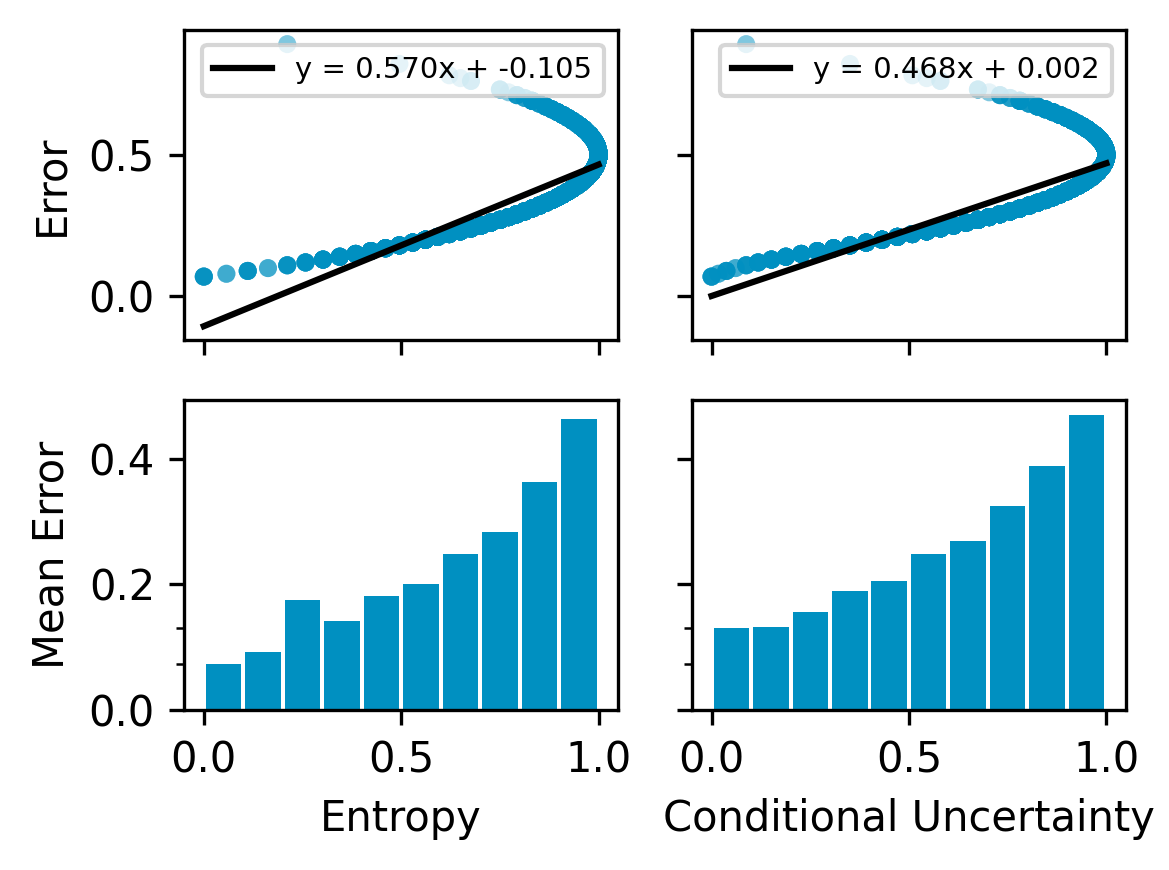

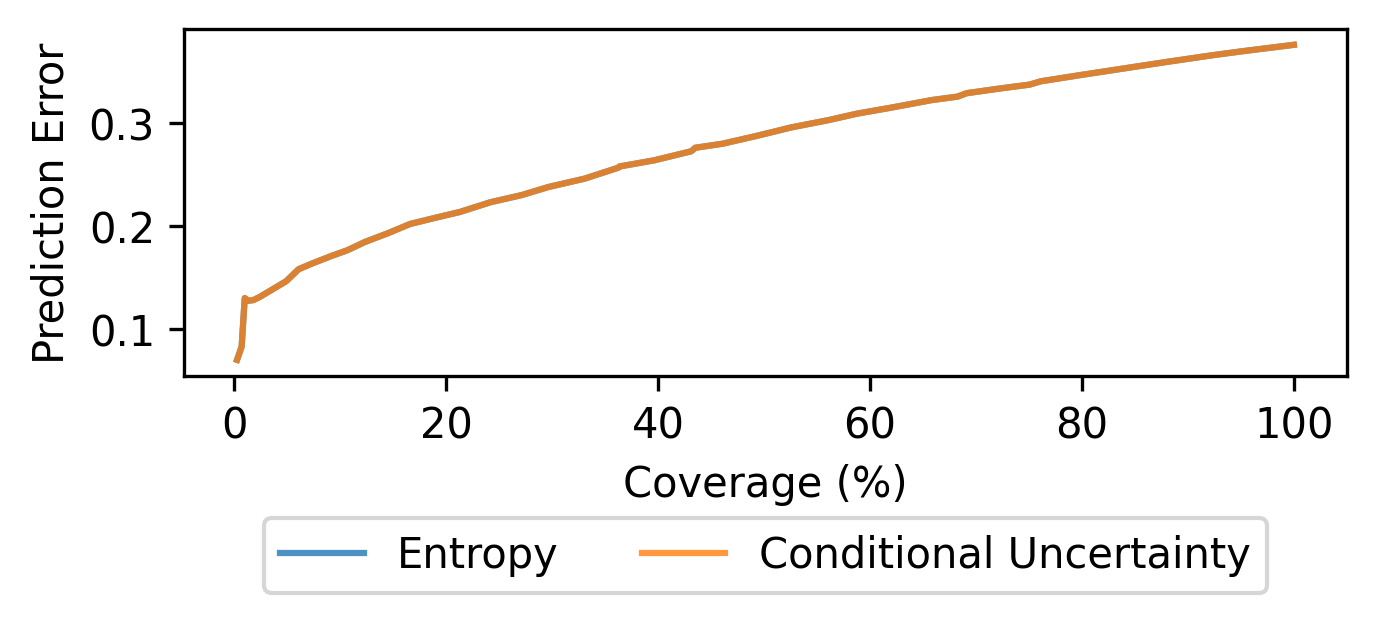

In [35]:
stat_dict = {
    "Entropy":{"ue":"entropy", "loss":"incorrect_class_prob"},
    "Conditional Uncertainty":{"ue":"uncertainty_prob", "loss":"incorrect_class_prob"}
}
survey_pred_dict = get_survey_information(
    model=crc_clf_w_pc, pred_dict=crc_pred_dict_w_pc, 
    feat_cols=best_feat_w_pc_oversampled, 
    target_col=crc_target_col_new, 
    stat_dict=stat_dict
)

In [36]:
survey_pred_dict["train_df"].iloc[:, -15:]

,colorectal cancer_pred,entropy,uncertainty_prob,uncertainty_prob_lb,uncertainty_prob_ub,incorrect_class_prob,colorectal cancer_pred_label,split,SBP_shap,DBP_shap,DASH_shap,BMI_shap,aMED_shap,Leisure screen time_shap,Age_interview_shap
SERNO,,,,,,,,,,,,,,,
3899,0.34,0.924819,0.397730,0.230517,0.564943,0.34,0.0,Train,0.029797,0.040034,-0.035271,0.038715,-0.004386,0.004635,0.086476
69938,0.49,0.999711,0.461655,0.294440,0.628871,0.49,0.0,Train,-0.035922,0.063247,0.026213,-0.027048,0.004772,0.002295,-0.023557
26886,0.17,0.657705,0.174547,0.017284,0.331810,0.17,0.0,Train,0.043769,0.050813,0.078116,0.019565,0.045665,0.004350,0.087722
61080,0.62,0.958042,0.426088,0.258873,0.593303,0.62,1.0,Train,0.032980,-0.023107,0.015661,0.004722,-0.013029,-0.003779,0.106552
16927,0.46,0.995378,0.457957,0.290741,0.625172,0.46,0.0,Train,0.025379,0.011426,0.053393,-0.013640,-0.002887,0.003542,-0.037213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44317,0.79,0.741483,0.241866,0.076400,0.407333,0.21,1.0,Train,0.052532,0.074371,0.045080,0.081792,0.009816,0.000960,0.025449
80088,0.92,0.402179,0.053188,-0.031715,0.138091,0.08,1.0,Train,0.038738,0.033088,0.053392,0.050954,0.023724,0.012749,0.207355
25575,0.81,0.701471,0.208890,0.046056,0.371724,0.19,1.0,Train,0.048013,0.038408,0.051819,0.060127,0.055505,0.020982,0.035146


In [37]:
joblib.dump(survey_pred_dict, "truncated_survey_pred_dict.joblib")

['truncated_survey_pred_dict.joblib']

In [33]:
survey_pred_dict = joblib.load("truncated_survey_pred_dict.joblib")
survey_pred_dict["val_df"]["uncertainty_prob"].describe()

count    2069.000000
mean        0.377061
std         0.095159
min         0.034720
25%         0.326604
50%         0.412978
75%         0.449794
max         0.461902
Name: uncertainty_prob, dtype: float64

In [70]:
old_survey_pred_dict = joblib.load("survey_pred_dict.joblib")
old_survey_pred_dict["val_df"]["uncertainty_prob"].describe()

count    2069.000000
mean        0.375099
std         0.101663
min        -0.147205
25%         0.326581
50%         0.412978
75%         0.449794
max         0.461902
Name: uncertainty_prob, dtype: float64

In [72]:
def select_survey_information(
    survey_pred_dict, selection_list, feat_cols, target_col, scaler, continuous_feats, df_name="test_df"):
    shap_cols = [f"{col}_shap" for col in feat_cols]
    pred_label_col = f"{target_col}_pred_label"
    uncertainty_col = "uncertainty_prob"
    lb_col, ub_col = "uncertainty_prob_lb", "uncertainty_prob_ub"
    correct_col = "correct"
    important_cols = (
        list(feat_cols) + shap_cols + 
        [target_col, pred_label_col, correct_col, uncertainty_col, lb_col, ub_col]
    )
    df = survey_pred_dict[df_name]
    df = df.copy()   
    df[continuous_feats] = scaler.inverse_transform(df[continuous_feats].values)
    df[correct_col] = df[target_col] == df[pred_label_col]
    all_selected_rows = []
    for selection_dict in selection_list:
        # Select class
        cur_df = df[df[target_col] == selection_dict["target_col"]]
        # Select prediction outcome
        cur_df = cur_df.loc[df[correct_col] == selection_dict["correct"]]
        # Select certainty
        selection_fn = selection_dict["uncertainty_selection_fn"]
        selected_uncertainty = selection_fn(cur_df[uncertainty_col])
        selected_row = cur_df[cur_df[uncertainty_col]==selected_uncertainty].head(1)
        all_selected_rows.append(selected_row)
    output_df = pd.concat(all_selected_rows)
    replacement_dict = {1:"Cancer", 0:"Normal"}
    output_df[pred_label_col] = output_df[pred_label_col].astype(int)
    output_df[pred_label_col] = output_df[pred_label_col].replace(replacement_dict)
    output_df[target_col] = output_df[target_col].replace(replacement_dict)
    output_df.loc[output_df["uncertainty_prob_lb"]<0, "uncertainty_prob_lb"] = 0
    return output_df[important_cols]

selection_list = [
    {"target_col": 1, "correct": True, "uncertainty_selection_fn": min}, # Cancer, Correct, Certain
    {"target_col": 1, "correct": False, "uncertainty_selection_fn": max}, # Cancer, Incorrect, Uncertain
    {"target_col": 0, "correct": True, "uncertainty_selection_fn": min}, # Normal, Correct, Certain
    {"target_col": 0, "correct": False, "uncertainty_selection_fn": max}, # Normal, Incorrect, Uncertain
]
selected_df = select_survey_information(
    survey_pred_dict, selection_list, 
    feat_cols=best_feat_w_pc_oversampled, target_col=crc_target_col_new, 
    scaler=crc_scaler, continuous_feats = crc_continuous_cols, df_name="test_df"
)
selected_df

,SBP,DBP,DASH,BMI,aMED,Leisure screen time,Age_interview,SBP_shap,DBP_shap,DASH_shap,BMI_shap,aMED_shap,Leisure screen time_shap,Age_interview_shap,colorectal cancer,colorectal cancer_pred_label,correct,uncertainty_prob,uncertainty_prob_lb,uncertainty_prob_ub
SERNO,,,,,,,,,,,,,,,,,,,,
48388,146.0,93.0,18.0,30.859375,0.0,3.5,60.000000,0.006265,0.008341,0.026027,0.064548,0.007349,-0.001307,0.088777,Cancer,Cancer,True,0.360580,0.193383,0.527777
70808,182.0,109.0,24.0,19.132653,4.0,3.5,69.256674,-0.010350,0.048715,0.040145,-0.034443,0.000100,-0.001367,-0.042800,Cancer,Normal,False,0.461902,0.294686,0.629117
7645,95.0,67.0,24.0,20.700817,4.0,3.5,53.930185,0.225030,0.035062,0.039377,0.034349,0.021939,0.001996,0.072247,Normal,Normal,True,0.046019,0.000000,0.122191
42017,148.0,91.0,23.0,18.285714,5.0,1.5,48.722793,0.025006,0.020008,-0.025648,0.020691,-0.001758,0.026127,-0.054427,Normal,Cancer,False,0.461655,0.294440,0.628871


Index: 48388


,Feature,Value
0,Systolic blood pressure (SBP),146.0
1,Diastolic blood pressure (DBP),93.0
2,DASH Diet Score (DASH),18.0
3,Body mass index (BMI),30.859375
4,aMED Diet Score (aMED),0.0
5,Leisure screen time (LST),3.5
6,Age,60.0


Prediction: Cancer
Uncertainty
Score: 36.1%
Bounds: 19.3-52.8%


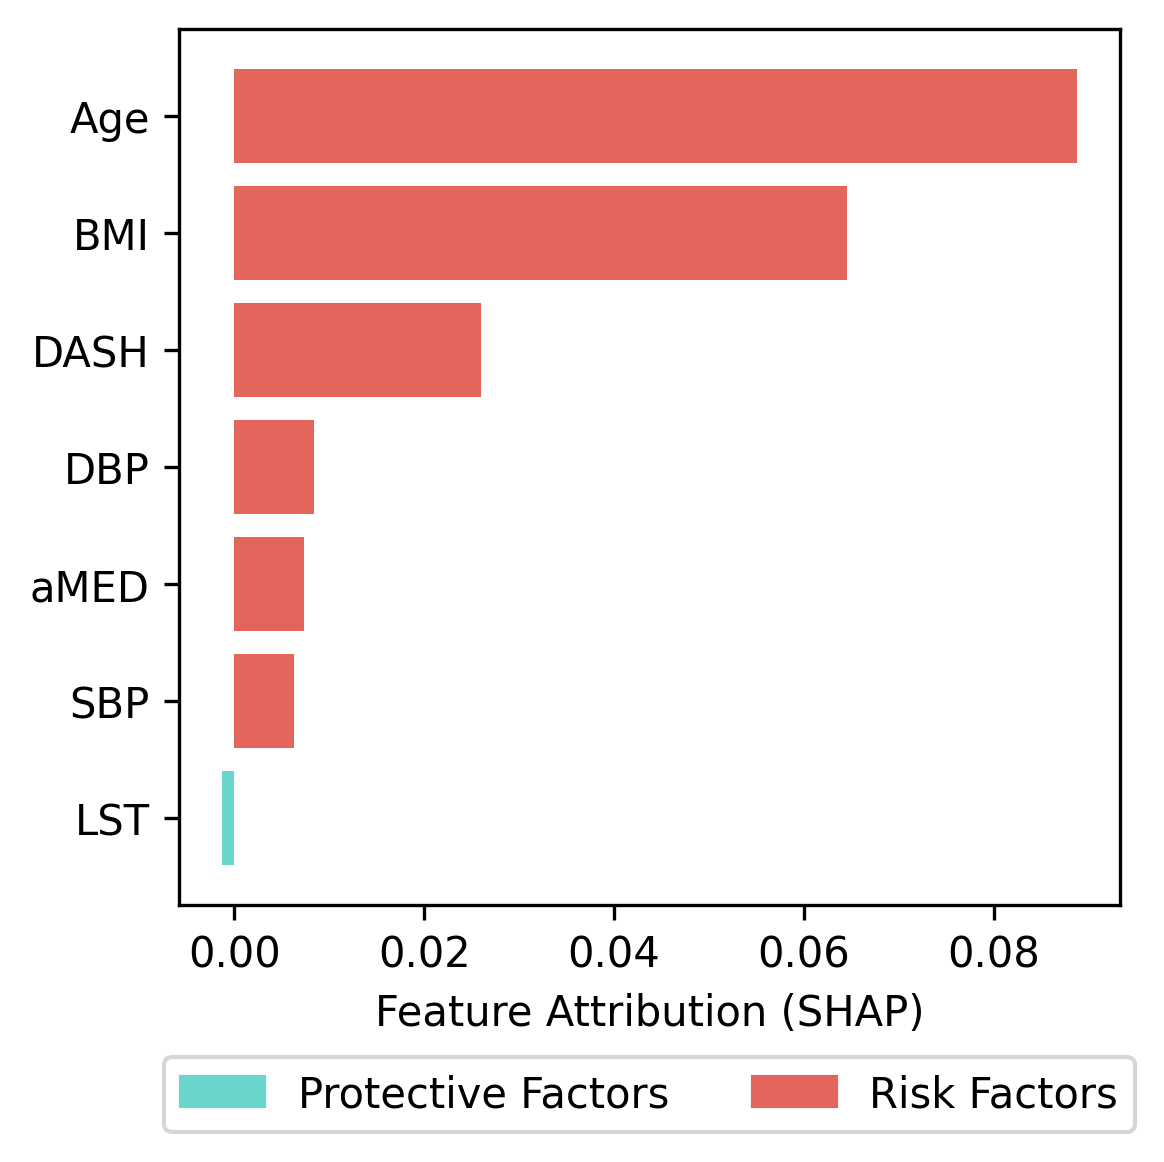


Index: 70808


,Feature,Value
0,Systolic blood pressure (SBP),182.0
1,Diastolic blood pressure (DBP),109.0
2,DASH Diet Score (DASH),24.0
3,Body mass index (BMI),19.132653
4,aMED Diet Score (aMED),4.0
5,Leisure screen time (LST),3.5
6,Age,69.256674


Prediction: Normal
Uncertainty
Score: 46.2%
Bounds: 29.5-62.9%


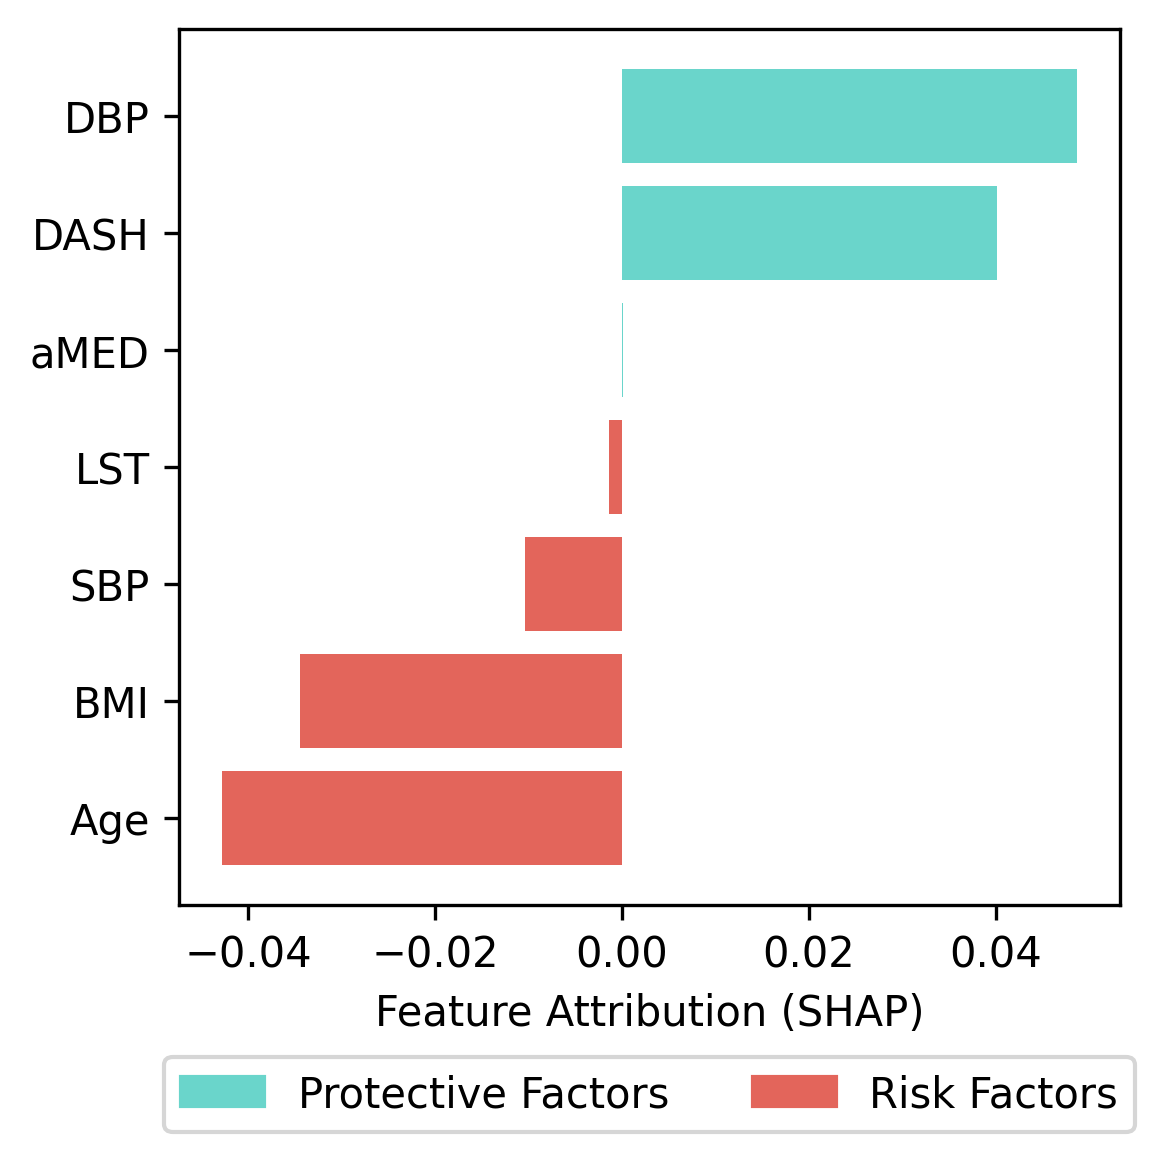


Index: 7645


,Feature,Value
0,Systolic blood pressure (SBP),95.0
1,Diastolic blood pressure (DBP),67.0
2,DASH Diet Score (DASH),24.0
3,Body mass index (BMI),20.700817
4,aMED Diet Score (aMED),4.0
5,Leisure screen time (LST),3.5
6,Age,53.930185


Prediction: Normal
Uncertainty
Score: 4.6%
Bounds: 0.0-12.2%


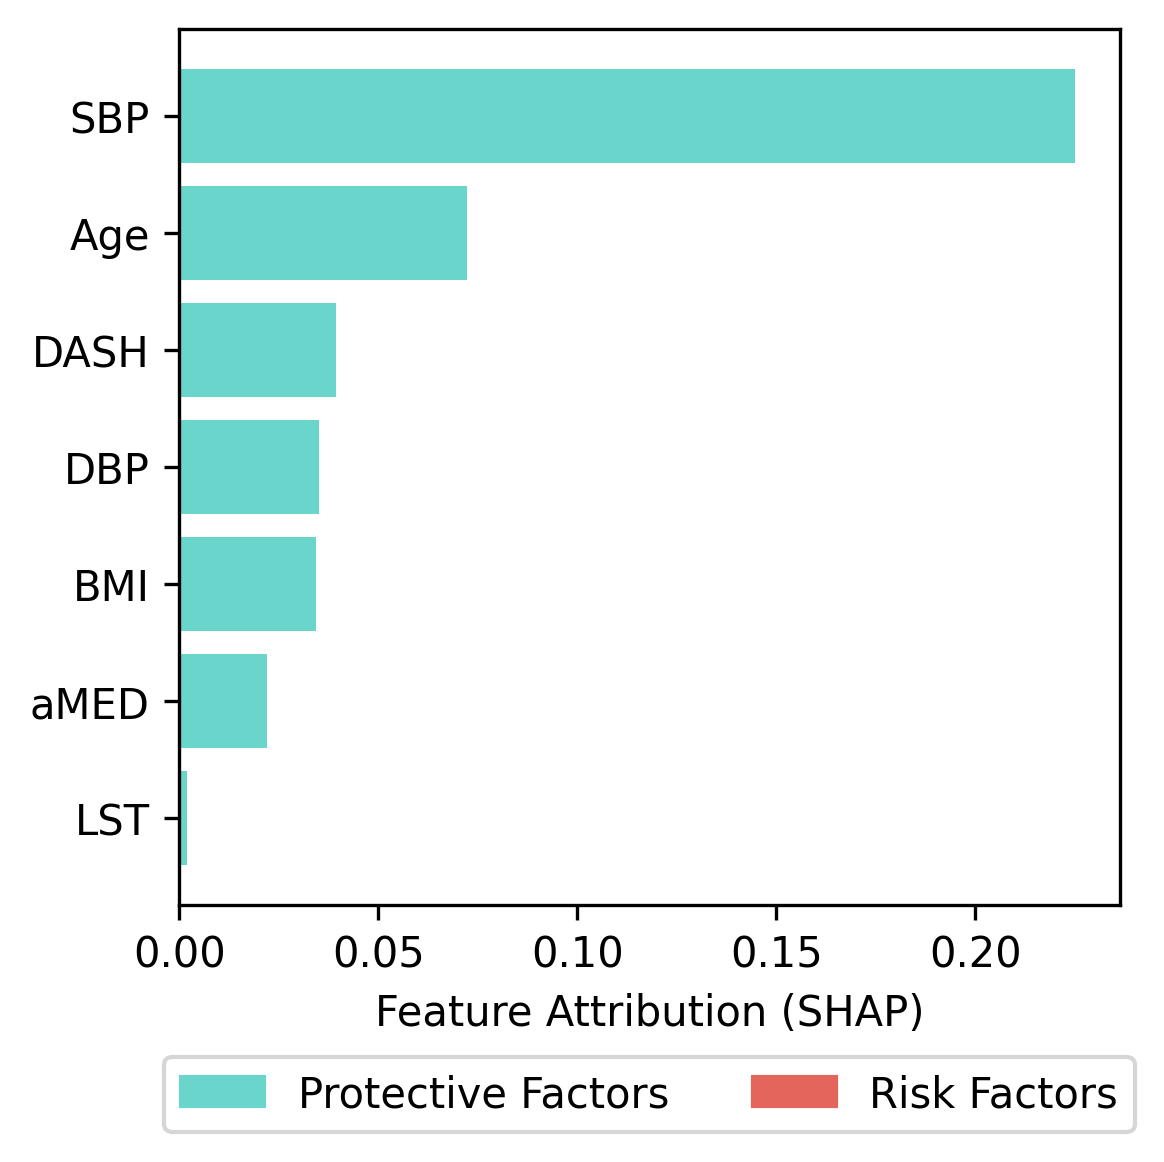


Index: 42017


,Feature,Value
0,Systolic blood pressure (SBP),148.0
1,Diastolic blood pressure (DBP),91.0
2,DASH Diet Score (DASH),23.0
3,Body mass index (BMI),18.285714
4,aMED Diet Score (aMED),5.0
5,Leisure screen time (LST),1.5
6,Age,48.722793


Prediction: Cancer
Uncertainty
Score: 46.2%
Bounds: 29.4-62.9%


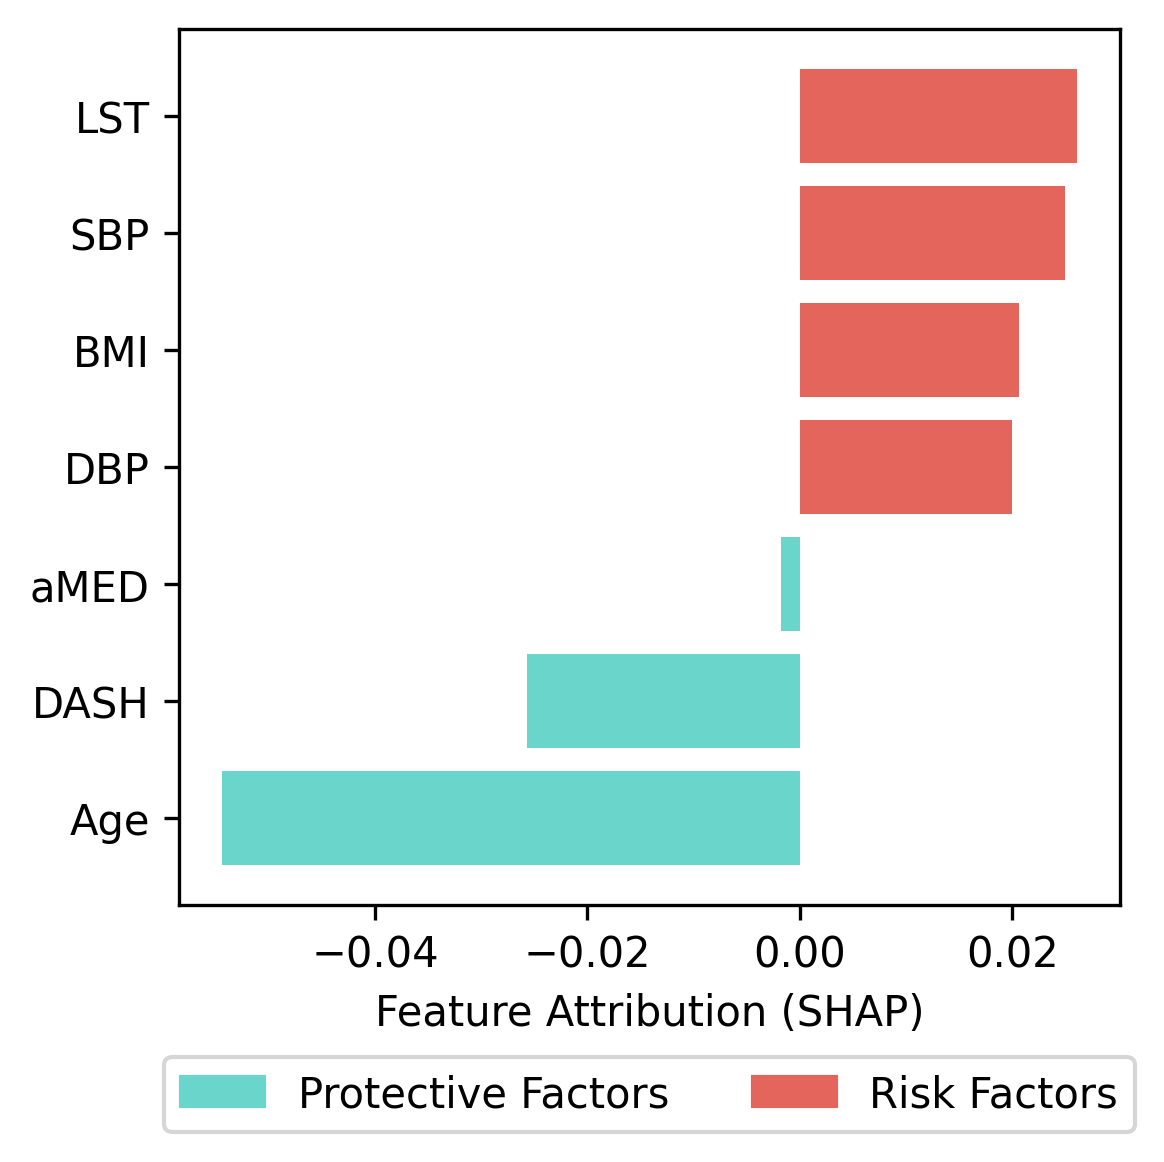

In [107]:
def display_survey_questions(selected_df, feat_cols, clean_feats, clean_shap_feats, target_col):
    pred_col = f"{target_col}_pred_label"
    uncertainty_col = "uncertainty_prob"
    lb_col, ub_col = "uncertainty_prob_lb", "uncertainty_prob_ub"
    shap_cols = [col+"_shap" for col in feat_cols]
    def row_to_df(old_feat_cols, new_feat_cols, row):
        feat_values = row[old_feat_cols].values
        return pd.DataFrame({"Feature":new_feat_cols, "Value":feat_values})
        
    for i in range(len(selected_df)):
        # Show patient features
        row = selected_df.iloc[i]
        print("Index:", row.name)
        patient_feature_df = row_to_df(feat_cols, clean_feats, row)
        display(patient_feature_df)
        
        # Show prediction
        pred = row[pred_col]
        print("Prediction:", pred)

        # Show uncertainty estimate
        uncertainty_prob = row[uncertainty_col]*100
        lb, ub = row[lb_col]*100, row[ub_col]*100
        print(f"Uncertainty")
        print(f"Score: {uncertainty_prob:.1f}%")
        print(f"Bounds: {lb:.1f}-{ub:.1f}%")

        # Show SHAP
        colors = {
            "Protective Factors": "#6AD5CB",
            "Risk Factors":"#E3655B"
        }
        fig, ax = plt.subplots(1, 1, dpi=300, figsize=(4, 4))
        shap_df = row_to_df(shap_cols, clean_shap_feats, row)
        shap_df = shap_df.sort_values(by="Value")
        if pred=="Normal":
            color_vec = [
                colors["Risk Factors"] if shap < 0 else colors["Protective Factors"] 
                for shap in shap_df["Value"]]
        else:
            color_vec = [
                colors["Protective Factors"] if shap < 0 else colors["Risk Factors"] 
                for shap in shap_df["Value"]]
        ax.barh(shap_df["Feature"], shap_df["Value"], color=color_vec)
        ax.set_xlabel("Feature Attribution (SHAP)")
        labels, handles = [], []
        for label, color in colors.items():
            labels.append(label)
            handles.append(plt.Rectangle((0,0),1,1, color=color))
        plt.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
        plt.tight_layout()
        plt.show()

        print()
        

clean_feats = [
    "Systolic blood pressure (SBP)", "Diastolic blood pressure (DBP)", 
    "DASH Diet Score (DASH)", "Body mass index (BMI)", "aMED Diet Score (aMED)", 
    "Leisure screen time (LST)", "Age"]
clean_shap_feats = ["SBP", "DBP", "DASH", "BMI", "aMED", "LST", "Age"]
display_survey_questions(
    selected_df, feat_cols=best_feat_w_pc_oversampled, target_col=crc_target_col_new, 
    clean_feats=clean_feats, clean_shap_feats=clean_shap_feats
)

In [80]:
crc_pred_dict_w_pc = get_shap_values(**crc_pred_dict_w_pc, feat_cols=crc_feat_cols_w_pc, target_col=crc_target_col_new, 
    clf=crc_clf_w_pc)

4. Getting Shap Values...
 - Instantiating Explainer...
4. Getting Explanations...


100%|████████████████████████████████████████████████████████████████████████████████| 259/259 [05:26<00:00,  1.26s/it]


 - Explanations for Training Set Took 326.85885190963745s


100%|██████████████████████████████████████████████████████████████████████████████████| 33/33 [00:41<00:00,  1.26s/it]


 - Explanations for Validation Set Took 41.73160219192505s


100%|██████████████████████████████████████████████████████████████████████████████████| 33/33 [00:41<00:00,  1.25s/it]

 - Explanations for Test Set Took 41.34808921813965s


In [81]:
joblib.dump(crc_pred_dict_w_pc, "crc_pred_dict_w_pc.joblib")

['crc_pred_dict_w_pc.joblib']

In [82]:
crc_pred_df_w_pc = format_results(
    **crc_pred_dict_w_pc, target_col=crc_target_col_new, scaler=crc_scaler, continuous_cols=crc_continuous_cols_new)
display(crc_pred_df_w_pc)

6. Generating Outputs...


,Follow-up time,colorectal cancer,Age_interview,PC1,PC2,PC3,BMI,telomere length,aHEI2010score,aMED,...,DASH_shap,SBP_shap,DBP_shap,Leisure screen time_shap,"Sex (0=Male, 1=Female)_shap",alcohol_DailyandWeekly(1)vsMonthlyandNonDrinkers(0)_shap,smoke_ex(1)_shap,smoke_current(2)_shap,split,colorectal cancer_pred_bin
SERNO,,,,,,,,,,,,,,,,,,,,,
3899,14.220397,0,56.960986,0.007232,-0.002803,0.009688,25.299376,0.896085,48.50915,5.0,...,-0.006288,-0.002601,0.011004,0.001566,0.033053,0.003484,0.004256,0.005898,train,0
69938,12.238193,0,67.315537,0.008885,-0.002439,0.007106,20.061728,0.820456,48.40260,2.0,...,0.009306,-0.005406,0.043074,0.003460,-0.016410,0.005326,0.002260,-0.022614,train,0
26886,14.568104,0,53.344285,-0.006410,0.002459,-0.003597,21.077195,0.846946,44.71553,6.0,...,0.019382,0.007544,0.052388,0.001123,-0.003121,0.005551,-0.023093,0.007856,train,0
61080,13.163587,0,63.961670,-0.006870,0.000689,-0.000106,21.453574,1.009318,63.92684,5.0,...,-0.018968,0.013717,0.002833,-0.000528,0.001948,-0.003054,-0.003255,-0.006561,train,1
16927,15.378508,0,62.269678,0.007468,-0.002034,0.014687,20.069204,0.951414,41.56957,4.0,...,0.017469,0.025267,0.011862,0.000174,-0.017609,0.004164,0.005298,0.006591,train,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52065,8.350445,1,59.501711,0.006170,0.004085,0.005871,24.221453,1.176846,48.96751,4.0,...,0.022499,0.015568,-0.020426,-0.005583,0.034202,-0.006537,0.030159,-0.004687,test,1
36771,2.236824,1,62.154689,-0.007565,0.009898,0.003430,19.909972,1.110349,45.72277,4.0,...,0.022459,-0.016035,0.007630,-0.000215,0.010526,0.002059,0.004388,0.004080,test,0
79121,7.186858,1,60.561259,-0.003018,0.002269,-0.003848,24.218750,1.009646,61.29827,5.0,...,-0.017415,0.025947,-0.011288,0.001163,-0.012477,-0.000999,-0.003341,-0.008769,test,1


In [83]:
def save_model_n_outputs(perf_df, pred_df, clf, name):
    fp_perf_pred_folder = os.path.join(fp_results_checkpoint_folder, name)
    if not os.path.exists(fp_perf_pred_folder):
        os.makedirs(fp_perf_pred_folder)
    fp_perf = os.path.join(fp_perf_pred_folder, "performance.csv")
    fp_pred = os.path.join(fp_perf_pred_folder, "prediction.csv")
    # Save perf and prediction
    perf_df.to_csv(fp_perf)
    pred_df.to_csv(fp_pred)
    # Save model
    fp_model = os.path.join(fp_model_checkpoint_folder, f"{name}.pickle")
    joblib.dump(clf, fp_model) 
    print("Saved!")
save_model_n_outputs(crc_perf_df_w_pc, crc_pred_df_w_pc, crc_clf_w_pc, name="crc_w_pc")

Saved!


In [19]:
def load_model_n_outputs(name):
    fp_perf_pred_folder = os.path.join(fp_results_checkpoint_folder, name)
    if not os.path.exists(fp_perf_pred_folder):
        print("Path does not exist!")
        return
    fp_perf = os.path.join(fp_perf_pred_folder, "performance.csv")
    fp_pred = os.path.join(fp_perf_pred_folder, "prediction.csv")
    perf_df = pd.read_csv(fp_perf, index_col=0)
    pred_df = pd.read_csv(fp_pred, index_col=0)
    fp_model = os.path.join(fp_model_checkpoint_folder, f"{name}.pickle")
    clf = joblib.load(fp_model)
    return perf_df, pred_df, clf
crc_perf_df_w_pc, crc_pred_df_w_pc, crc_clf_w_pc = load_model_n_outputs(name="crc_w_pc")
display(crc_perf_df_w_pc)
display(crc_pred_df_w_pc)

,AUC,Accuracy,Loss
Train,0.999894,0.881034,0.467324
Valid,0.572856,0.851136,0.496981
Test,0.596498,0.844369,0.492384


,Follow-up time,colorectal cancer,Age_interview,PC1,PC2,PC3,BMI,telomere length,aHEI2010score,aMED,...,DASH_shap,SBP_shap,DBP_shap,Leisure screen time_shap,"Sex (0=Male, 1=Female)_shap",alcohol_DailyandWeekly(1)vsMonthlyandNonDrinkers(0)_shap,smoke_ex(1)_shap,smoke_current(2)_shap,split,colorectal cancer_pred_bin
SERNO,,,,,,,,,,,,,,,,,,,,,
3899,14.220397,0,56.960986,0.007232,-0.002803,0.009688,25.299376,0.896085,48.50915,5.0,...,-0.006288,-0.002601,0.011004,0.001566,0.033053,0.003484,0.004256,0.005898,train,0
69938,12.238193,0,67.315537,0.008885,-0.002439,0.007106,20.061728,0.820456,48.40260,2.0,...,0.009306,-0.005406,0.043074,0.003460,-0.016410,0.005326,0.002260,-0.022614,train,0
26886,14.568104,0,53.344285,-0.006410,0.002459,-0.003597,21.077195,0.846946,44.71553,6.0,...,0.019382,0.007544,0.052388,0.001123,-0.003121,0.005551,-0.023093,0.007856,train,0
61080,13.163587,0,63.961670,-0.006870,0.000689,-0.000106,21.453574,1.009318,63.92684,5.0,...,-0.018968,0.013717,0.002833,-0.000528,0.001948,-0.003054,-0.003255,-0.006561,train,1
16927,15.378508,0,62.269678,0.007468,-0.002034,0.014687,20.069204,0.951414,41.56957,4.0,...,0.017469,0.025267,0.011862,0.000174,-0.017609,0.004164,0.005298,0.006591,train,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52065,8.350445,1,59.501711,0.006170,0.004085,0.005871,24.221453,1.176846,48.96751,4.0,...,0.022499,0.015568,-0.020426,-0.005583,0.034202,-0.006537,0.030159,-0.004687,test,1
36771,2.236824,1,62.154689,-0.007565,0.009898,0.003430,19.909972,1.110349,45.72277,4.0,...,0.022459,-0.016035,0.007630,-0.000215,0.010526,0.002059,0.004388,0.004080,test,0
79121,7.186858,1,60.561259,-0.003018,0.002269,-0.003848,24.218750,1.009646,61.29827,5.0,...,-0.017415,0.025947,-0.011288,0.001163,-0.012477,-0.000999,-0.003341,-0.008769,test,1


In [85]:
crc_pred_df_w_pc["colorectal cancer_pred_bin"].value_counts()

colorectal cancer_pred_bin
0    17719
1     2970
Name: count, dtype: int64

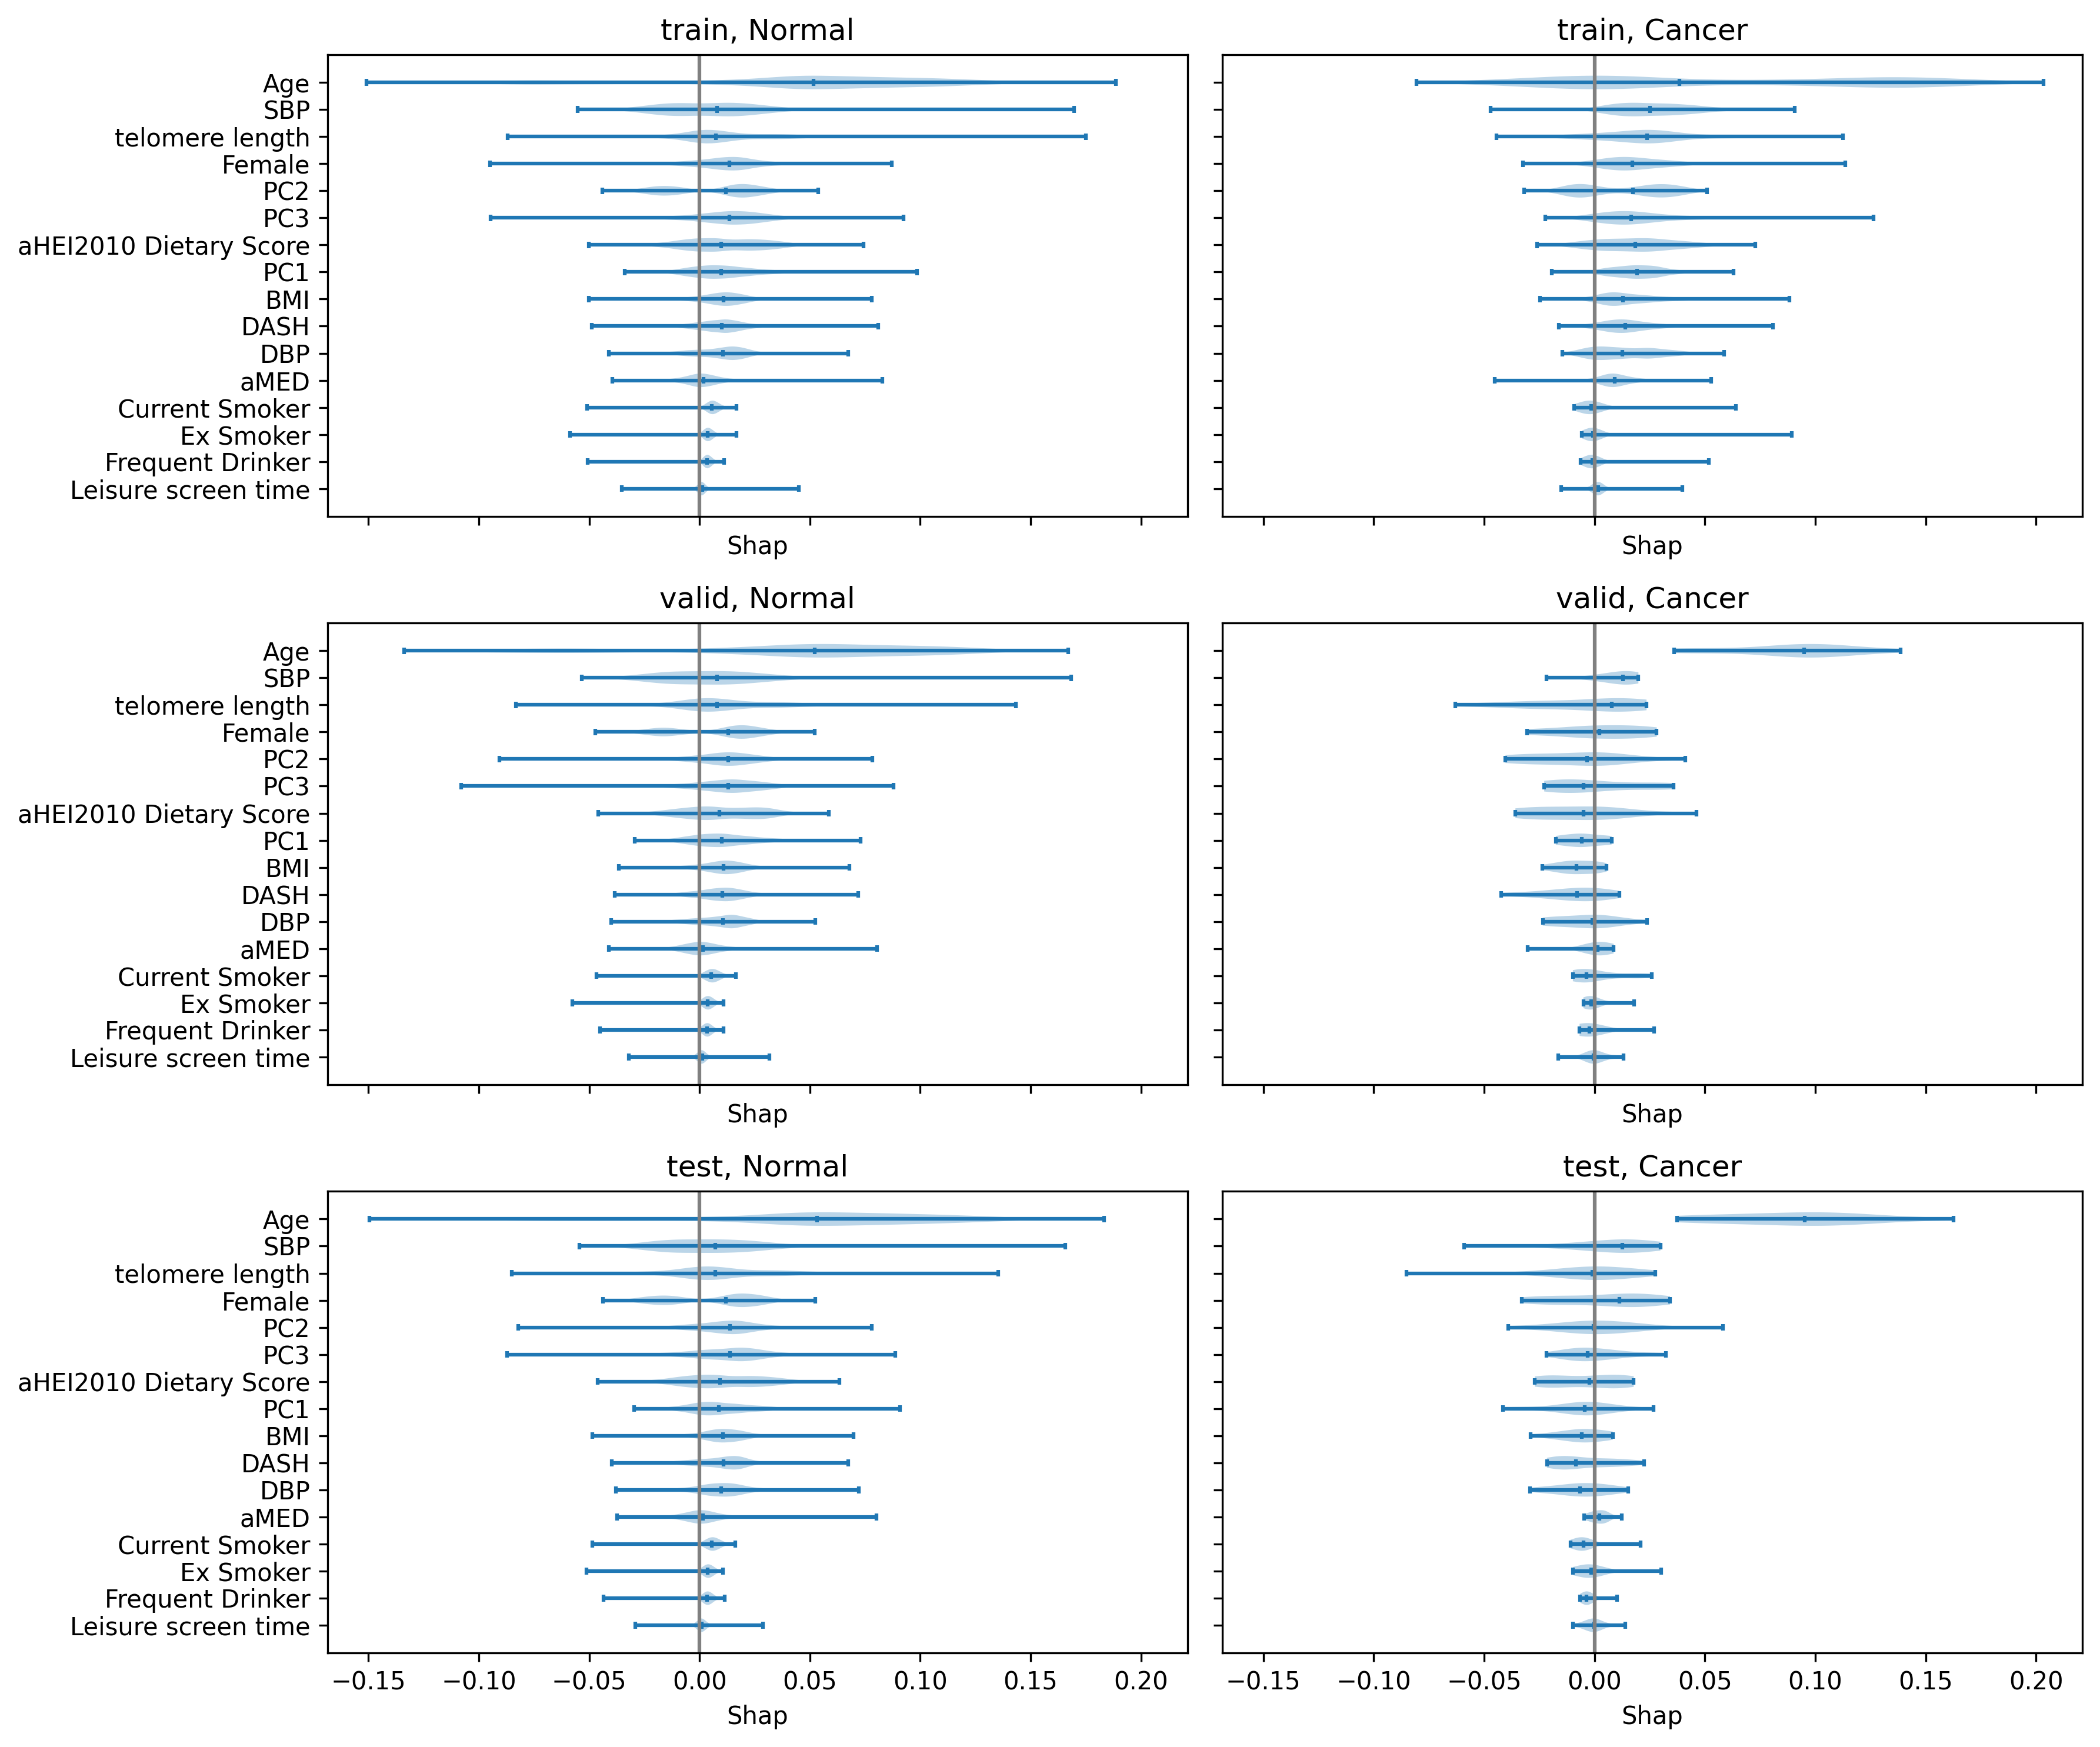

In [144]:
def visualise_global_shap_crc(pred_df, feat_cols, target_col):   
    columns_to_replace ={
        "Age_interview_shap": "Age_shap", 
        'aHEI2010score_shap':"aHEI2010 Dietary Score_shap", 
        "LeisureScreenTime_shap": "Leisure Screen Time_shap",
        "Sex (0=Male, 1=Female)_shap": "Female_shap",
        'alcohol_DailyandWeekly(1)vsMonthlyandNonDrinkers(0)_shap': "Frequent Drinker_shap",
        'smoke_ex(1)_shap': "Ex Smoker_shap",
       'smoke_current(2)_shap': "Current Smoker_shap"
    }
    class_label_list = ["Normal", "Cancer"]
    
    pred_df = pred_df.copy()
    shap_cols = [f"{col}_shap" for col in feat_cols]
    pred_bin_col = f"{target_col}_pred_bin"

    # Get correct predictions
    pred_df = pred_df[pred_df[target_col] == pred_df[pred_bin_col]]

    # Plot Shap Values
    fig, axes = plt.subplots(3, 2, figsize=(12, 10), dpi=300, sharey=True, sharex=True) #
    for i, split_name in enumerate(["train", "valid", "test"]):
        split_df = pred_df[pred_df["split"]==split_name]
        sorted_cols = split_df[shap_cols].abs().mean().sort_values().index
        for j, (class_label, class_df) in enumerate(split_df.groupby(target_col)):
            sorted_df = class_df[sorted_cols]
            sorted_df = sorted_df.rename(columns=columns_to_replace)
            axes[i, j].violinplot(sorted_df, showmedians=True, vert=False)
            axes[i, j].set_yticks(range(1, len(shap_cols)+1))
            axes[i, j].set_yticklabels([col[:-5] for col in sorted_df.columns])
            axes[i, j].set_title(f"{split_name}, {class_label_list[class_label]}")
            axes[i, j].set_xlabel("Shap")
            axes[i, j].axvline(0, color='grey')
    plt.tight_layout()
    
visualise_global_shap_crc(
    pred_df=crc_pred_df_w_pc, feat_cols=crc_feat_cols_w_pc, target_col=crc_target_col_new)

Index: 32074 , Split: test


,Value
Feature,
Class,Cancer
Age,62.519
Male,
BMI,28.283
aMED,3.0
telomere length,1.061
DBP,78.0
PC2,0.0
Leisure screen time,3.5


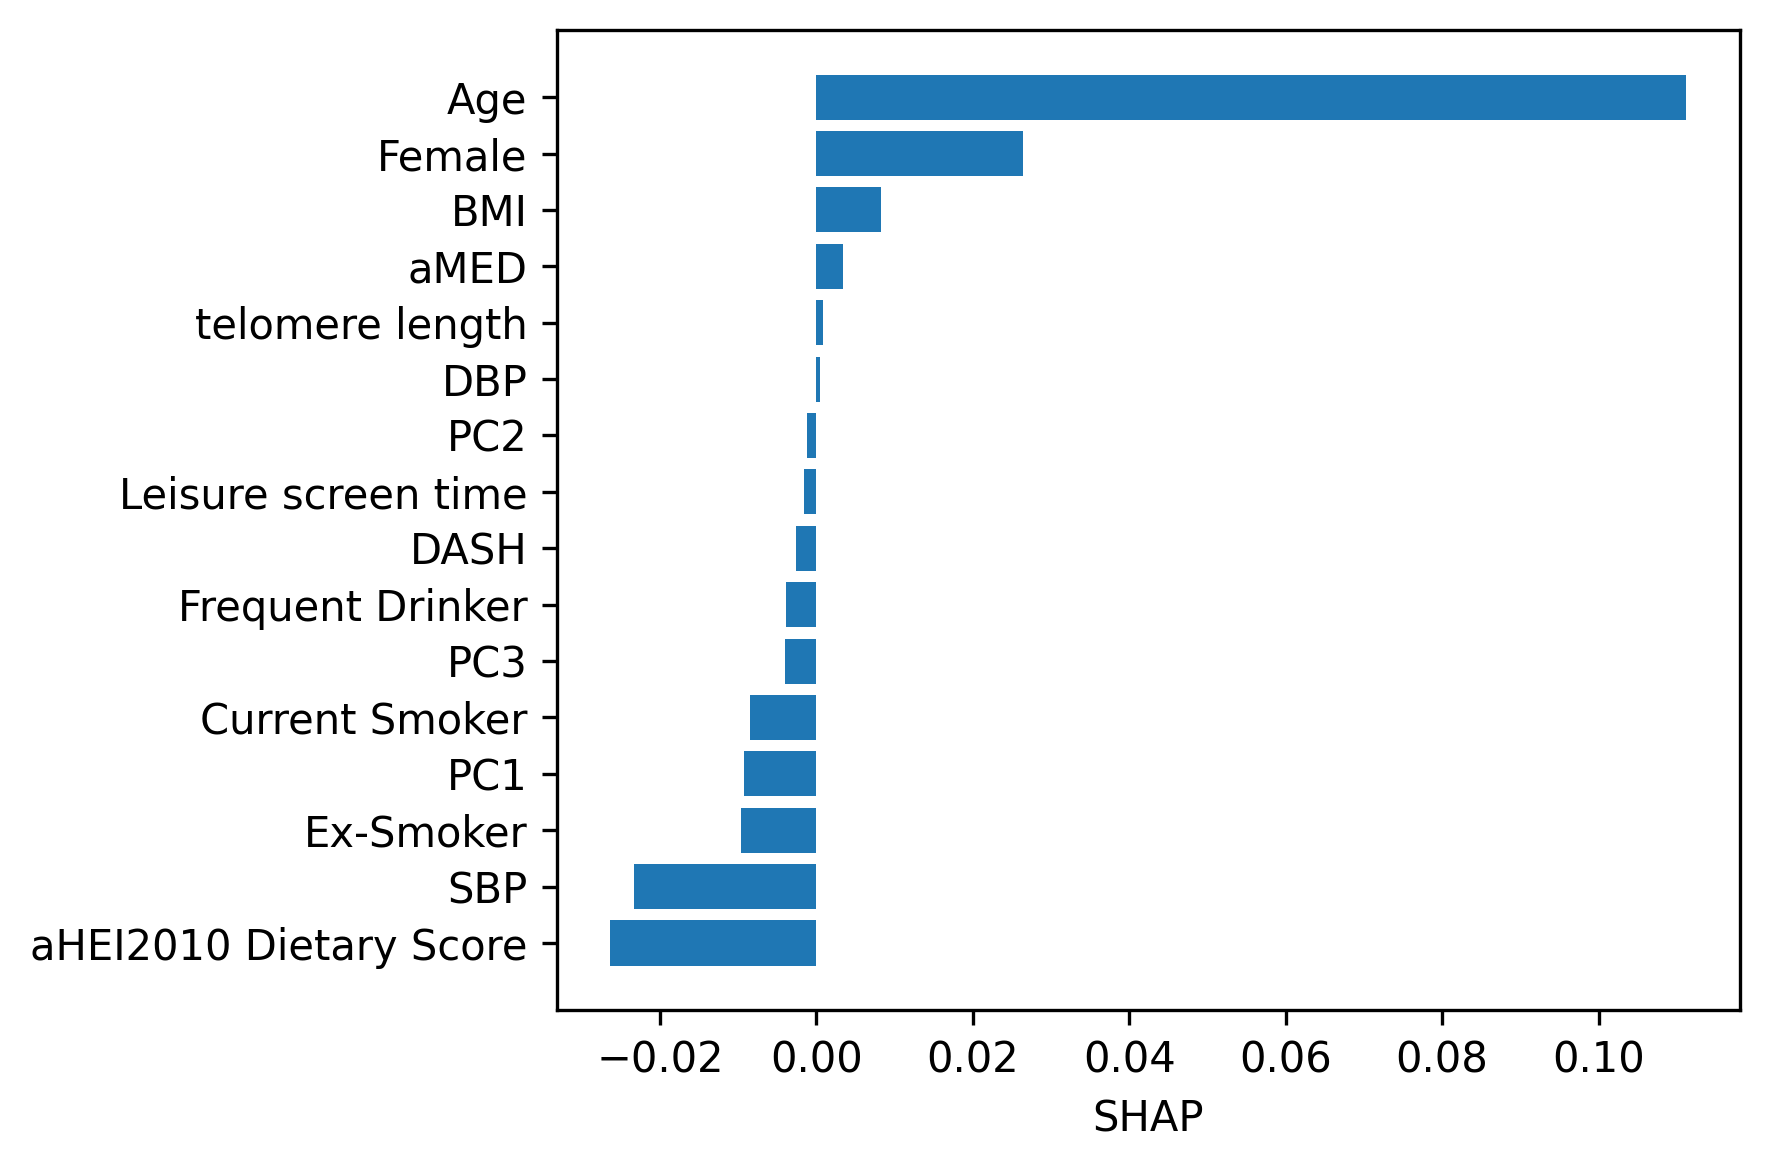

In [50]:
def visualise_local_shap_crc(pred_df, feat_cols, target_col, condition_series, continuous_cols, categorical_cols, scaler):
    columns_to_replace = {
        "Age_interview": "Age", 
        'aHEI2010score':"aHEI2010 Dietary Score", 
        "LeisureScreenTime": "Leisure Screen Time",
        "Sex (0=Male, 1=Female)": "Female",
        'alcohol_DailyandWeekly(1)vsMonthlyandNonDrinkers(0)': "Frequent Drinker",
        'smoke_ex(1)': "Ex-Smoker",
       'smoke_current(2)': "Current Smoker"
    }
    shap_columns_to_replace = {
        "Age_interview_shap": "Age_shap", 
        'aHEI2010score_shap':"aHEI2010 Dietary Score_shap", 
        "LeisureScreenTime_shap": "Leisure Screen Time_shap",
        "Sex (0=Male, 1=Female)_shap": "Female_shap",
        'alcohol_DailyandWeekly(1)vsMonthlyandNonDrinkers(0)_shap': "Frequent Drinker_shap",
        'smoke_ex(1)_shap': "Ex-Smoker_shap",
       'smoke_current(2)_shap': "Current Smoker_shap"
    }
    cat_column_conversion = {
        "Female": ["Male", "Female"],
        "Frequent Drinker": ["Infrequent Drinker", "Frequent Drinker"],
        "Smoker": ["Never Smoked", "Ex-Smoker", "Current Smoker"]
    }
    new_feat_cols = [columns_to_replace[col] if col in columns_to_replace else col for col in feat_cols]
    new_cat_cols = [columns_to_replace[col] if col in columns_to_replace else col for col in categorical_cols]
    class_label_list = ["Normal", "Cancer"]
    
    pred_df = pred_df.copy()
    shap_cols = [f"{col}_shap" for col in feat_cols]
    pred_bin_col = f"{target_col}_pred_bin"

    # Change shap names
    pred_df = pred_df.rename(columns=shap_columns_to_replace)
    shap_cols = [col for col in pred_df.columns if "_shap" in col]
        
    # Get row
    row = pred_df[condition_series].iloc[0]

    # Plot Shap Values
    shaps = row[shap_cols].sort_values(ascending=True)
    fig, ax = plt.subplots(1, 1, dpi=300, figsize=(6, 4))
    display_shap_cols = [col[:-5] for col in shaps.index]
    ax.barh(display_shap_cols, shaps)
    ax.set_xlabel("SHAP")
    plt.tight_layout()

    feat_df = []
    # Rename value columns
    pred_df = pred_df.rename(columns=columns_to_replace)
    row = pred_df[condition_series].iloc[0]
    print("Index:", row.name, ", Split:", row["split"])
    feat_df.append({"Feature": "Class", "Value": class_label_list[row[target_col]]})
    smoker_flag = False # Mark if smoker status has been printed
    for col in display_shap_cols[::-1]:
        if col in new_cat_cols:
            if col in cat_column_conversion:
                feat_df.append({"Feature": cat_column_conversion[col][row[col]], "Value": ""})
            elif "Smoker" in col and not smoker_flag:
                if row["Ex-Smoker"] == 1:
                    feat_df.append({"Feature": cat_column_conversion['Smoker'][1], "Value": ""})
                elif row["Current Smoker"] == 1:
                    feat_df.append({"Feature": cat_column_conversion['Smoker'][2], "Value": ""})
                else:
                    feat_df.append({"Feature": cat_column_conversion['Smoker'][0], "Value": ""})
                smoker_flag = True
        else:
            feat_df.append({"Feature": col, "Value": round(row[col], 3)})
    feat_df = pd.DataFrame(feat_df)
    feat_df = feat_df.set_index('Feature')
    display(feat_df)
    feat_df.to_clipboard()
        
visualise_local_shap_crc(
    pred_df=crc_pred_df_w_pc, feat_cols=crc_feat_cols_w_pc, target_col=crc_target_col_new, 
    condition_series=(
        (crc_pred_df_w_pc["split"]=="test") & 
        (crc_pred_df_w_pc['Sex (0=Male, 1=Female)']==0) & 
        (crc_pred_df_w_pc['colorectal cancer_pred']>0.5) &
        (crc_pred_df_w_pc['colorectal cancer']>0.5)
    ),
    continuous_cols=crc_continuous_cols_new, categorical_cols=crc_categorical_cols_new, scaler=crc_scaler
)

In [88]:
def get_balanced_statistics(pred_df, target_col, seed=seed):
    from sklearn.metrics import log_loss, accuracy_score, roc_auc_score
    pred_df = pred_df.copy()
    class_1_df = pred_df[(pred_df["split"]=="test") & (pred_df[target_col]==1)]
    class_0_df = pred_df[(pred_df["split"]=="test") & (pred_df[target_col]==0)]
    class_0_df = class_0_df.sample(len(class_1_df), random_state=seed)
    new_test_pred_df = pd.concat([class_0_df, class_1_df])
    pred_col = target_col + "_pred"
    
    perf_df = pd.DataFrame(dict(
        AUC = [
            roc_auc_score(new_test_pred_df[target_col], new_test_pred_df[pred_col])],
        Accuracy = [
            accuracy_score(new_test_pred_df[target_col], new_test_pred_df[pred_col]>0.5)],
        Loss = [
            log_loss(new_test_pred_df[target_col], new_test_pred_df[pred_col])], 
    ), index=["Test Undersampled"])

    return perf_df

def repeatedly_get_balanced_statistics(iterations, pred_df, target_col, seed=seed):
    all_perf_df = []
    for i in tqdm(range(iterations), total=iterations):
        all_perf_df.append(get_balanced_statistics(pred_df=pred_df, target_col=target_col, seed=seed+i))
    new_perf_df = pd.concat(all_perf_df).mean().to_frame().T
    new_perf_df.index = ["Test Undersampled"]
    return new_perf_df

repeatedly_get_balanced_statistics(
    iterations=1000, pred_df=crc_pred_df_w_pc, target_col=crc_target_col_new, seed=seed)


100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:20<00:00, 49.33it/s]


,AUC,Accuracy,Loss
Test Undersampled,0.597218,0.56112,0.701768


#### Without PC

In [103]:
crc_best_estimators_wo_pc, crc_tuning_df_wo_pc = tune_model_crc(
    train_df=crc_split_dict_encoded["train_df"], 
    val_df=crc_split_dict_encoded["val_df"], 
    feat_cols=crc_feat_cols_wo_pc, 
    target_col=crc_target_col_new,
    n_estimators_list=[600, 650, 700, 750, 800], 
    seed=seed
)
print(f"Optimal Number of Estimators: {crc_best_estimators_wo_pc}")
display(crc_tuning_df_wo_pc)

Number of Trees = 800: 100%|█████████████████████████████████████████████████████████████| 5/5 [00:56<00:00, 11.24s/it]

Optimal Number of Estimators: 700


,Number of Trees,Training Accuracy,Validation Accuracy,Training AUC,Validation AUC,Training Loss,Validation Loss,Train Time/s,Best Hyperparamter
0,600,0.879343,0.840503,0.999961,0.589581,0.468935,0.500148,6.799436,False
1,650,0.880491,0.841469,0.999963,0.591050,0.469018,0.499651,8.629181,False
2,700,0.879947,0.841469,0.999971,0.591541,0.469257,0.499698,8.946309,True
3,750,0.879524,0.839536,0.999972,0.589899,0.469081,0.499769,9.267481,False
4,800,0.878618,0.838569,0.999972,0.590924,0.469139,0.499787,9.762328,False


In [97]:
crc_tuning_df_wo_pc.to_csv(fp_crc_tuning_wo_pc_file)

In [104]:
crc_best_estimators_wo_pc=700	

In [129]:
crc_clf_wo_pc = train_model_crc(
    **crc_split_dict_encoded, feat_cols=crc_feat_cols_wo_pc, target_col=crc_target_col_new, 
    n_estimators=crc_best_estimators_wo_pc, seed=seed
)

1. Training The Model...
 - Training Took 10.733750343322754s


In [130]:
crc_pred_dict_wo_pc, crc_perf_df_wo_pc = get_predictions(
    **crc_split_dict_encoded, feat_cols=crc_feat_cols_wo_pc, target_col=crc_target_col_new, 
    clf=crc_clf_wo_pc)
display(crc_perf_df_wo_pc)

2. Predicting...
 - Prediction for Training Set Took 2.303497791290283s
 - Prediction for Validation Set Took 0.42168116569519043s
 - Prediction for Test Set Took 0.5012669563293457s
3. Evaluating...


,AUC,Accuracy,Loss
Train,0.999971,0.879947,0.469257
Valid,0.591541,0.841469,0.499698
Test,0.602615,0.842436,0.497009


In [133]:
crc_pred_dict_wo_pc = get_shap_values(
    **crc_pred_dict_wo_pc, feat_cols=crc_feat_cols_wo_pc, target_col=crc_target_col_new, 
    clf=crc_clf_wo_pc, chunksize=256)

4. Getting Shap Values...
 - Instantiating Explainer...
4. Getting Explanations...


100%|██████████████████████████████████████████████████████████████████████████████████| 33/33 [04:00<00:00,  7.30s/it]

 - Explanations for Test Set Took 240.7681586742401s


In [134]:
crc_pred_df_wo_pc = format_results(
    **crc_pred_dict_wo_pc, target_col=crc_target_col_new, scaler=crc_scaler, continuous_cols=crc_continuous_cols_new)
display(crc_pred_df_wo_pc)

6. Generating Outputs...


,Follow-up time,colorectal cancer,Age_interview,PC1,PC2,PC3,BMI,telomere length,aHEI2010score,aMED,...,DASH_shap,SBP_shap,DBP_shap,Leisure screen time_shap,"Sex (0=Male, 1=Female)_shap",alcohol_DailyandWeekly(1)vsMonthlyandNonDrinkers(0)_shap,smoke_ex(1)_shap,smoke_current(2)_shap,split,colorectal cancer_pred_bin
SERNO,,,,,,,,,,,,,,,,,,,,,
65490,13.779603,0,54.907598,0.006683,0.002754,0.007109,20.703125,1.120204,56.21376,7.0,...,-0.001995,-0.021173,0.016950,0.013406,-0.018257,0.001693,0.007302,0.009284,test,0
7420,3.436003,0,59.071869,0.006576,-0.000338,0.004525,22.313278,1.094503,46.78005,2.0,...,-0.026080,-0.025084,0.015721,0.002154,0.046202,0.005860,0.002473,0.007558,test,0
16435,12.511978,0,54.305270,-0.008706,-0.000870,0.000584,17.585265,1.037741,45.28755,3.0,...,-0.008084,-0.013858,-0.000868,0.006247,0.040829,0.004245,0.003455,-0.014434,test,0
53621,11.893224,0,46.874743,0.007056,0.012698,-0.016343,20.761246,0.781553,52.38056,4.0,...,0.003006,0.019039,-0.010927,0.012538,-0.018160,0.003694,-0.053552,0.004979,test,0
76482,13.297741,0,53.853525,0.006224,0.006598,-0.004088,23.326792,1.195203,43.71500,3.0,...,0.031005,-0.004019,0.028836,-0.012931,-0.029021,0.005481,-0.025520,0.006025,test,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52065,8.350445,1,59.501711,0.006170,0.004085,0.005871,24.221453,1.176846,48.96751,4.0,...,0.031871,0.009696,-0.009124,-0.011538,0.036362,-0.008136,0.022766,-0.006455,test,1
36771,2.236824,1,62.154689,-0.007565,0.009898,0.003430,19.909972,1.110349,45.72277,4.0,...,-0.027362,0.023610,-0.014104,0.000567,-0.017207,-0.003053,-0.001713,-0.004904,test,1
79121,7.186858,1,60.561259,-0.003018,0.002269,-0.003848,24.218750,1.009646,61.29827,5.0,...,0.007473,-0.020918,0.000794,0.000773,0.014312,0.003171,0.002295,0.008461,test,0


In [135]:
save_model_n_outputs(crc_perf_df_wo_pc, crc_pred_df_wo_pc, crc_clf_wo_pc, name="crc_wo_pc")

Saved!


In [43]:
crc_perf_df_wo_pc, crc_pred_df_wo_pc, crc_clf_wo_pc = load_model_n_outputs(name="crc_wo_pc")
display(crc_perf_df_wo_pc)
display(crc_pred_df_wo_pc)

,AUC,Accuracy,Loss
Train,0.999971,0.879947,0.469257
Valid,0.591541,0.841469,0.499698
Test,0.602615,0.842436,0.497009


,Follow-up time,colorectal cancer,Age_interview,PC1,PC2,PC3,BMI,telomere length,aHEI2010score,aMED,...,DASH_shap,SBP_shap,DBP_shap,Leisure screen time_shap,"Sex (0=Male, 1=Female)_shap",alcohol_DailyandWeekly(1)vsMonthlyandNonDrinkers(0)_shap,smoke_ex(1)_shap,smoke_current(2)_shap,split,colorectal cancer_pred_bin
SERNO,,,,,,,,,,,,,,,,,,,,,
65490,13.779603,0,54.907598,0.006683,0.002754,0.007109,20.703125,1.120204,56.21376,7.0,...,-0.001995,-0.021173,0.016950,0.013406,-0.018257,0.001693,0.007302,0.009284,test,0
7420,3.436003,0,59.071869,0.006576,-0.000338,0.004525,22.313278,1.094503,46.78005,2.0,...,-0.026080,-0.025084,0.015721,0.002154,0.046202,0.005860,0.002473,0.007558,test,0
16435,12.511978,0,54.305270,-0.008706,-0.000870,0.000584,17.585265,1.037741,45.28755,3.0,...,-0.008084,-0.013858,-0.000868,0.006247,0.040829,0.004245,0.003455,-0.014434,test,0
53621,11.893224,0,46.874743,0.007056,0.012698,-0.016343,20.761246,0.781553,52.38056,4.0,...,0.003006,0.019039,-0.010927,0.012538,-0.018160,0.003694,-0.053552,0.004979,test,0
76482,13.297741,0,53.853525,0.006224,0.006598,-0.004088,23.326792,1.195203,43.71500,3.0,...,0.031005,-0.004019,0.028836,-0.012931,-0.029021,0.005481,-0.025520,0.006025,test,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52065,8.350445,1,59.501711,0.006170,0.004085,0.005871,24.221453,1.176846,48.96751,4.0,...,0.031871,0.009696,-0.009124,-0.011538,0.036362,-0.008136,0.022766,-0.006455,test,1
36771,2.236824,1,62.154689,-0.007565,0.009898,0.003430,19.909972,1.110349,45.72277,4.0,...,-0.027362,0.023610,-0.014104,0.000567,-0.017207,-0.003053,-0.001713,-0.004904,test,1
79121,7.186858,1,60.561259,-0.003018,0.002269,-0.003848,24.218750,1.009646,61.29827,5.0,...,0.007473,-0.020918,0.000794,0.000773,0.014312,0.003171,0.002295,0.008461,test,0


In [137]:
crc_pred_df_w_pc["colorectal cancer_pred_bin"].value_counts()

colorectal cancer_pred_bin
0    17719
1     2970
Name: count, dtype: int64

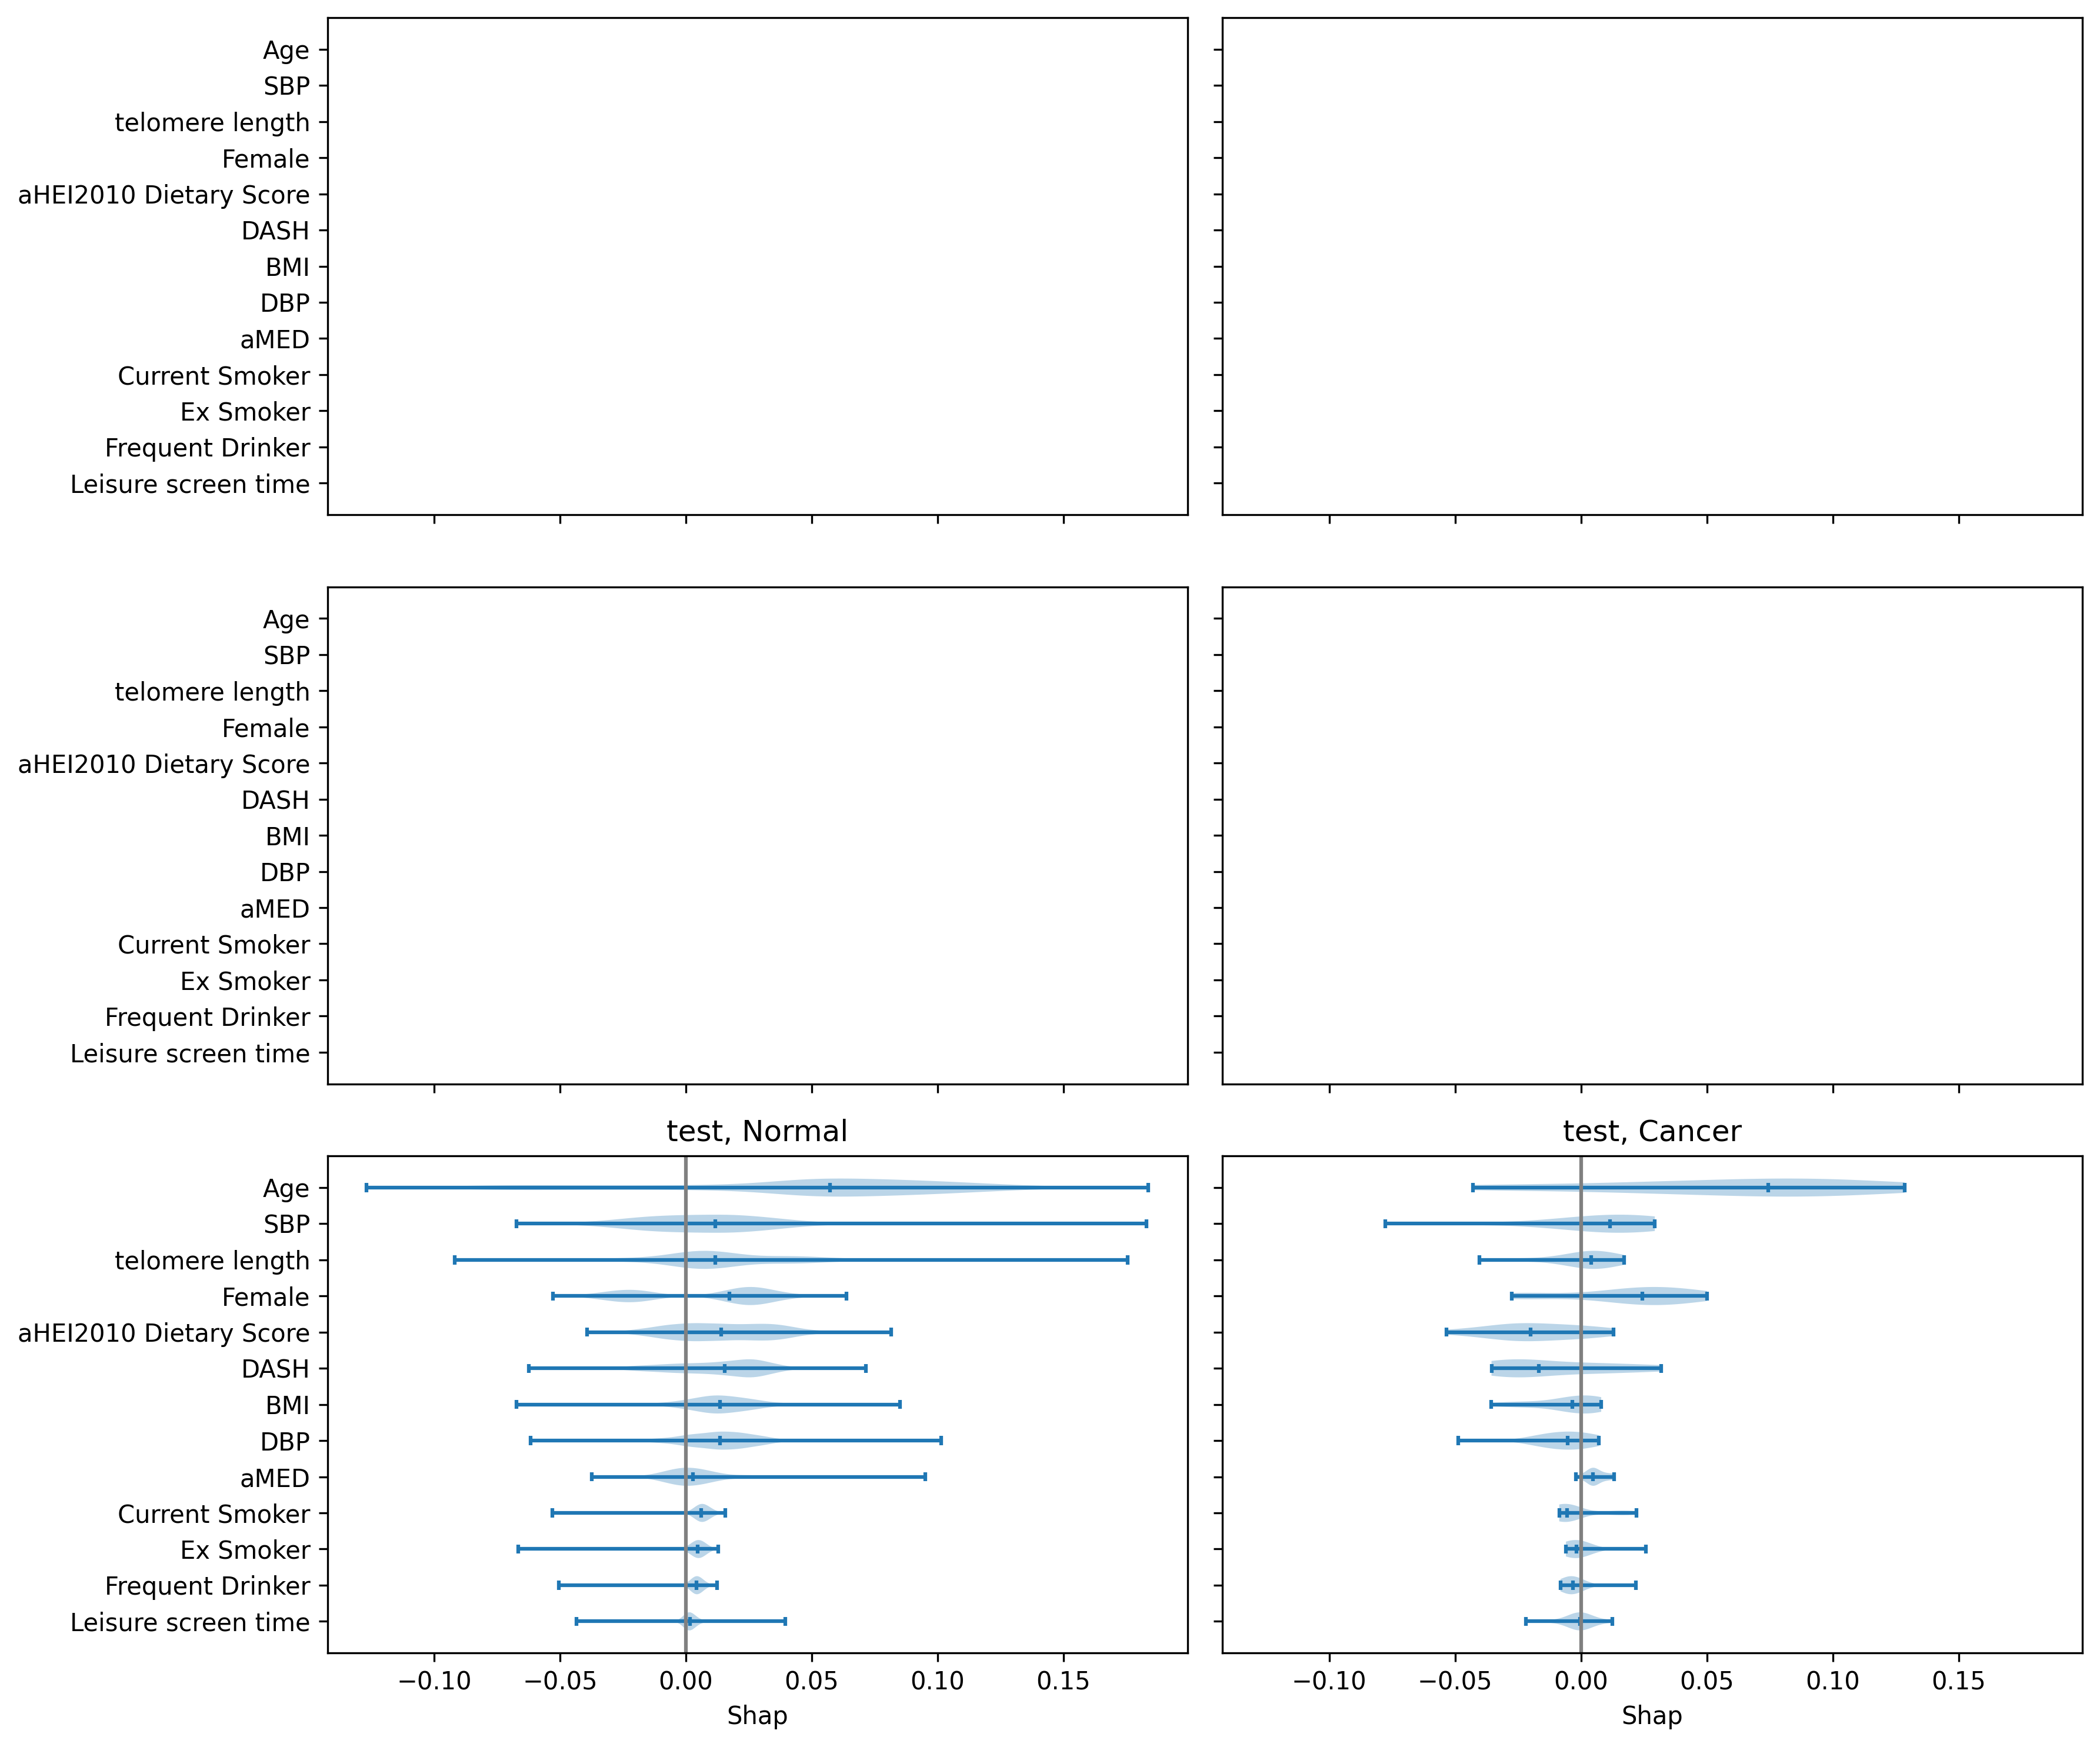

In [145]:
visualise_global_shap_crc(
    pred_df=crc_pred_df_wo_pc, feat_cols=crc_feat_cols_wo_pc, target_col=crc_target_col_new)

Index: 32074 , Split: test


,Value
Feature,
Class,Cancer
Age,62.519
Male,
telomere length,1.061
BMI,28.283
aMED,3.0
Leisure screen time,3.5
DBP,78.0
Never Smoked,


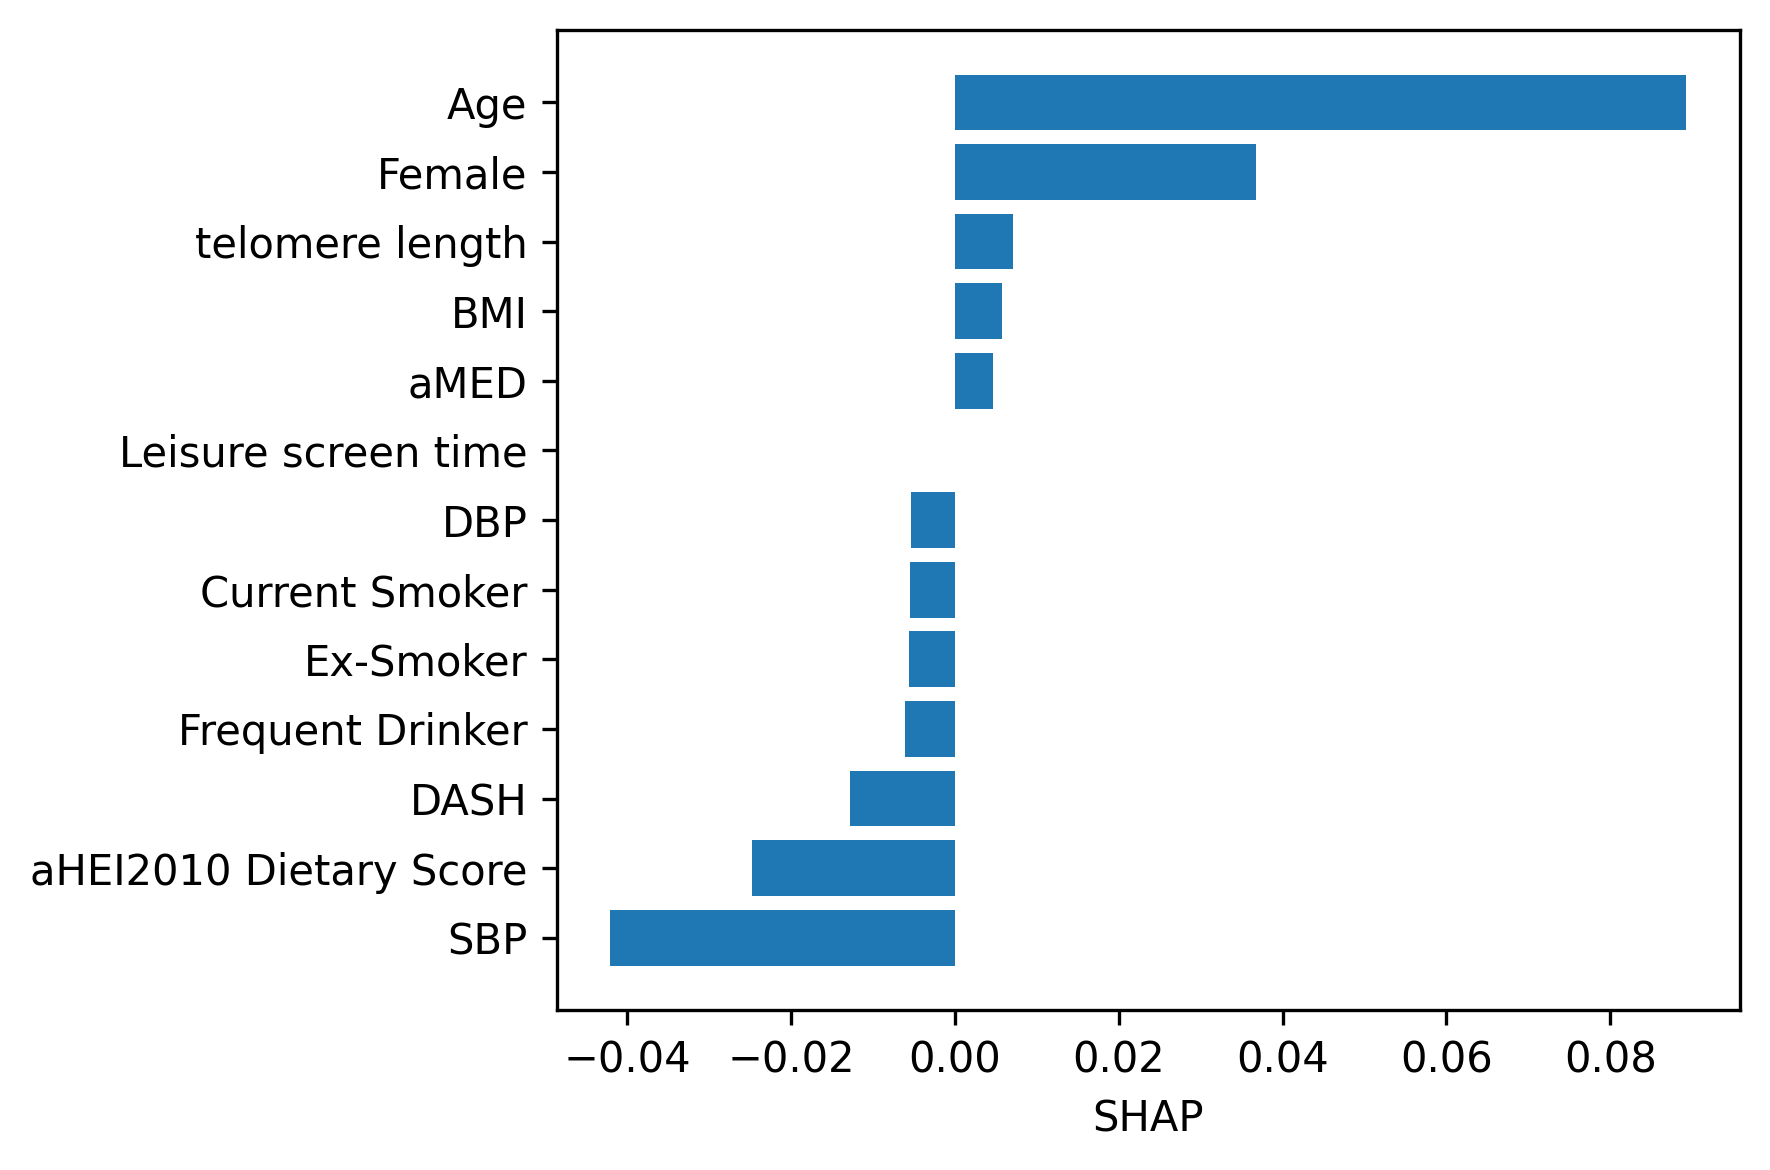

In [48]:
visualise_local_shap_crc(
    pred_df=crc_pred_df_wo_pc, feat_cols=crc_feat_cols_wo_pc, target_col=crc_target_col_new, 
    condition_series=(
        (crc_pred_df_wo_pc["split"]=="test") & 
        (crc_pred_df_wo_pc['Sex (0=Male, 1=Female)']==0) & 
        (crc_pred_df_wo_pc['colorectal cancer_pred']>0.5) &
        (crc_pred_df_wo_pc['colorectal cancer']>0.5)
    ),
    continuous_cols=crc_continuous_cols_new, categorical_cols=crc_categorical_cols_new, scaler=crc_scaler
)

In [140]:
repeatedly_get_balanced_statistics(
    iterations=1000, pred_df=crc_pred_df_wo_pc, target_col=crc_target_col_new, seed=seed)

100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:12<00:00, 82.79it/s]


,AUC,Accuracy,Loss
Test Undersampled,0.604337,0.56063,0.704562
